# Datos abiertos de Airbnb en la ciudad de New York

Autores:
    - Santiago López Aristizábal
    - Arnoll Mauricio Florez Perez

Objetivo: Tomar un dataset público de Airbnb y crear un modelo capaz de predecir los precios de los inmuebles inscritos a la aplicación en la ciudad de New York 

Dataset: Contiene la información abierta de los alojamientos de Airbnb en la ciudad de New York. Se puede descargar en https://insideairbnb.com/get-the-data/ y el diccionario de la data en https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596 donde se tomo la última versión de listings.csv.

Resumen general del proceso realizado:
1. Obtener la data.
2. Preparación de la data:
    - Eliminación de columnas sin relevancia para el precio de los alojamientos.
    - Busquedad de duplicados.
    - Eliminación de datos pre-pandemia.
    - Reformateo de columnas.
    - Imputación de datos faltantes.
    - Creación de característica de distancia mínima a lugares turísticos.
    - Creación de características con base en las comodidades de los alojamientos:
        * Clusterización con base en modelo de sentence-transformers (https://huggingface.co/sentence-transformers/all-MiniLM-L12-v2).
    - Limpieza de outliers en variable objetivo e independientes.
3. Entrenamiento de modelos:
    - Elección de modelos de regresión:
        * Multi Layer Perceptron (MLP) sin tener en cuenta las comodidades, solo datos estructurales  del alojamiento, ubicación y reseña.
        * Multi Layer Perceptron (MLP) tomando en cuenta la clusterización de las comodidades.
        * Multi Layer Perceptron (MLP) tomando como base la clusterización de las comodidades para crear variables booleanas.
        * Extreme Gradient Boosting tomando como base la clusterización de las comodidades para crear variables booleanas.
    - Creación inicial de modelos
    - Afinación de modelos.
4. Comparación de modelos
    - Resultados de R² por modelo
5. Publicación en interfaz gráfica



## 1. Librerias y configuraciones previas

In [225]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np
import ast
import re
from collections import Counter


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math

# Preparación de datos
# ==============================================================================
from sklearn.neighbors import LocalOutlierFactor
from geopy.distance import geodesic
import umap

# Preprocesado y modelado
# ==============================================================================

# Creación y entrenamiento de modelos
import joblib
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sentence_transformers import SentenceTransformer
import hdbscan

# Escalar Variables
from sklearn.preprocessing import StandardScaler

# Evaluacion de variables
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [226]:
import sys
# Rutas
# ==============================================================================
DATASET_PATH = 'datasets/'
MODELOS_PATH = 'modelos/'

## 2. Funciones

In [ ]:
def reformat_true_false_columns(df, columns):
    for col in columns:
        df[col] = df[col].fillna('f')
        df[col] = df[col].map({'t': True, 'f': False})
    return df

def reformat_price_column(df, column):
    df[column] = df[column].str.replace('$', '').str.replace(',', '').astype(float)
    return df

import re

def normalize_amenity(a):
    a = a.lower().strip()
    # STREAMING
    streaming_pattern = r'netflix|hbo|max|disney|amazon prime video|hulu|roku|apple tv|chromecast|fire tv'
    a = re.sub(streaming_pattern, 'streaming', a)
    # NORMALIZAR TV
    a = re.sub(r'hdtv|smart tv', 'tv', a)
    # NORMALIZAR TV CABLE
    cable_pattern = r'premium cable|standard cable|cable tv'
    a = re.sub(cable_pattern, 'cable', a)
    # WIFI
    a = re.sub(r'fast wifi', 'wifi', a)
    # REFRIGERATOR
    a = re.sub(r'refrirator|refridgerator|refridgerater', 'refrigerator',a)
    # ELIMINAR NÚMEROS
    a = re.sub(r'\d+', '', a)
    # ELIMINAR UNIDADES
    a = re.sub(r'mbps|gbps|inch|inches', '', a)
    # ELIMINAR MARCAS
    brand_pattern = r'samsung|bose|sonos|lg|ge|bosch|frigidaire|whirlpool|amana|smeg'
    a = re.sub(brand_pattern, '', a)
    # ELIMINAR STOPWORDS
    stop_words_pattern = r'available|upon request|specific hours|extra cost|days a week|every day|hours|day|week'
    a = re.sub(stop_words_pattern, '', a)
    # ELIMINAR "with"
    a = re.sub(r'\bwith\b', '', a)
    # ELIMINAR SÍMBOLOS
    a = re.sub(r'[^a-z\s]', '', a)
    # ELIMINAR STREAMING REPETIDO
    a = re.sub(r'(streaming\s*)+', 'streaming ', a)
    # ELIMINAR CABLE REPETIDO
    a = re.sub(r'(cable\s*)+', 'streaming ', a)
    # COLAPSAR ESPACIOS
    a = re.sub(r'\s+', ' ', a)

    return a.strip()

def format_amenities_to_text(text: str) -> str:
    text = text.replace("[", "").replace("]", "")  # Limpiar corchetes
    text = text.replace("'", "").replace('"', "")  # Limpiar comillas
    text = text.strip().strip(",")                 # Separar por comas
    # Convierte a oración natural con prefijo
    return "This place offers: " + text

def map_amenities(lst):
    mapped = set()
    for amenity in lst:
        for label, pattern in patterns.items():
            if re.search(pattern, amenity):
                mapped.add(label)
    return list(mapped)

In [228]:
# Sitios turísticos en New York City con sus coordenadas (latitud, longitud)
sitios_turisticos = {
    'statue_of_liberty': (40.6892, -74.0445),
    'central_park': (40.785091, -73.968285),
    'empire_state': (40.748817, -73.985428),
    'museo_metropolitano_de_arte_(met)': (40.7794, -73.9632),
    'time_square': (40.7580, -73.9855),
    'brooklyn_bridge': (40.7061, -73.9969),
    'vessel': (40.7532, -74.0020),
    'september_11_memorial': (40.7115, -74.0134),
    'madison_square_garden': (40.7505, -73.9934),
    'rockefeller_center': (40.7587, -73.9787),
    'museo_americano_historia_natural': (40.7813, -73.9735),
}

def distancia_minima_turistica(lat, lon):
    """Calcula la distancia mínima (en km) desde una coordenada a los sitios turísticos de NYC."""
    distancias = [
        geodesic((lat, lon), coords).km
        for coords in sitios_turisticos.values()
    ]
    return min(distancias)

In [229]:
# Funciones externas
# ==============================================================================

from utils.funciones import multiple_plot

## 3. Carga del dataset

In [230]:
#Cargar el dataset
data = pd.read_csv(DATASET_PATH +'listings.csv')

## 4. Limpieza de datos (Data Cleaning)

In [231]:
#Borrando columnas que no se utilizarán
data.drop(['listing_url','scrape_id','last_scraped','source','name','description','neighborhood_overview','picture_url','host_url','host_name','host_since','host_location','host_about','host_response_time','host_response_rate','host_acceptance_rate','host_is_superhost','host_thumbnail_url','host_picture_url','host_neighbourhood','host_listings_count','host_total_listings_count','host_verifications','host_has_profile_pic','host_identity_verified','neighbourhood','neighbourhood_cleansed','neighbourhood_group_cleansed','property_type','minimum_nights','maximum_nights','minimum_minimum_nights','maximum_minimum_nights','minimum_maximum_nights','maximum_maximum_nights','minimum_nights_avg_ntm','maximum_nights_avg_ntm','calendar_updated','has_availability','availability_30','availability_60','availability_90','availability_365','calendar_last_scraped','number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d','availability_eoy','number_of_reviews_ly','estimated_occupancy_l365d','estimated_revenue_l365d','first_review','calculated_host_listings_count','calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms','reviews_per_month','review_scores_rating','review_scores_accuracy','review_scores_cleanliness','review_scores_checkin','review_scores_communication','review_scores_location'], axis='columns', inplace=True)


Vamos a revisar si hay registros duplicados

In [232]:
datos_duplicados = data.duplicated()
print(f"Número de filas duplicadas: {datos_duplicados.sum()}")

Número de filas duplicadas: 0


In [233]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 36403 entries, 0 to 36402
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   36403 non-null  int64  
 1   host_id              36403 non-null  int64  
 2   latitude             36403 non-null  float64
 3   longitude            36403 non-null  float64
 4   room_type            36403 non-null  str    
 5   accommodates         36403 non-null  int64  
 6   bathrooms            21546 non-null  float64
 7   bathrooms_text       36276 non-null  str    
 8   bedrooms             30483 non-null  float64
 9   beds                 21495 non-null  float64
 10  amenities            36403 non-null  str    
 11  price                21279 non-null  str    
 12  last_review          25093 non-null  str    
 13  review_scores_value  25056 non-null  float64
 14  license              5466 non-null   str    
 15  instant_bookable     36403 non-null  str    
dt

La columna "license" es la que mayor cantidad de valores nulos presenta, así que vamos a analizarla

In [234]:
data['license'].unique()

<StringArray>
[                 nan, 'OSE-STRREG-0000008', 'OSE-STRREG-0001970',
 'OSE-STRREG-0001150', 'OSE-STRREG-0000108', 'OSE-STRREG-0001710',
             'Exempt', 'OSE-STRREG-0000041', 'OSE-STRREG-0000832',
 'OSE-STRREG-0001784',
 ...
 'OSE-STRREG-0003141', 'OSE-STRREG-0003088', 'OSE-STRREG-0003148',
 'OSE-STRREG-0003182', 'OSE-STRREG-0001929', 'OSE-STRREG-0003180',
 'OSE-STRREG-0002772', 'OSE-STRREG-0003191', 'OSE-STRREG-0003196',
 'OSE-STRREG-0001043']
Length: 1979, dtype: str

Vemos que la mayoría de los registros inician con "OSE-STRREG", esto hace referencia al OSE Short Term Rental Registration de la ciudad de New York. Así que revisemos los que no contenga ese string en la licencia.

In [235]:
data[~data['license'].str.upper().str.contains('OSE-STRREG', na=False)]['license'].unique()

<StringArray>
[nan, 'Exempt']
Length: 2, dtype: str

Lo que se observa de la columna "license", es que se tienen alojamientos licenciados, otros exentos y el resto sin licencia, así que se trabajará como una variable booleana, agrupando los licenciados con los exentos.

In [236]:
data['license'] = (
    data['license'].str.upper().str.contains('OSE-STRREG', na=False)
    | data['license'].str.contains('Exempt', na=False)
)


Ahora se convertira la columna "last_review" a un tipo de dato datetime para facilitar su manipulación

In [237]:
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')

Se crea una nueva columna con el año de la última reseña y el año de inscripción del host en Airbnb

In [238]:
data['year_last_review'] = data['last_review'].dt.year.astype('Int64')

# Se borra la columna con las fecha completa
data.drop(['last_review'], axis='columns', inplace=True)

Ahora analicemos esta nueva columna

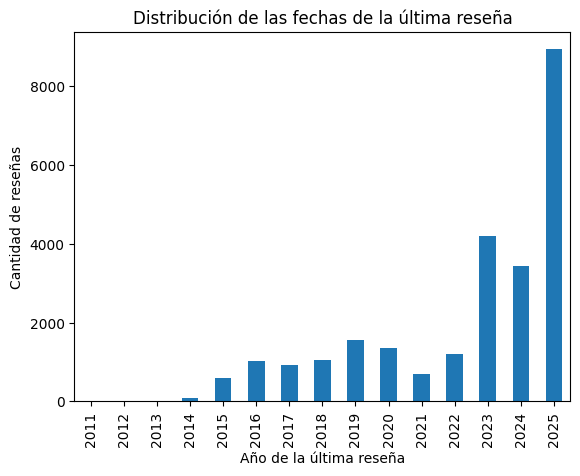

In [239]:
data['year_last_review'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de las fechas de la última reseña')
plt.xlabel('Año de la última reseña')
plt.ylabel('Cantidad de reseñas')
plt.show()

Se tienen alojamientos cuya última reseña fue hace más de 10 años y es probable que ya no estén en funcionamiento, esto puede distorsionar el análisis de la oferta de alojamientos actualmente, ya que aunque para los huéspedes no sea obligatorio realizar una reseña de los alojamientos, que no se tengan reseñas en tanto tiempo es poco probable, adicionalmente tomando en cuenta la pandemia del COVID-19 durante su apogeo en el 2020 se presento una caída drástica en las reservas por las diferentes medidas de cuarentena implementadas por los gobiernos, es decir que fue un año muy atípico para el turismo a nivel mundial y posiblemente muchos de los alojamientos tuvieron que cerrar, incluso de la tabla anterior se observa que hay una disminución en la cantidad de reseñas, por este motivo se dropearan los registros anteriores al 2022 para tener la data más reciente.

In [240]:
data.drop(data[data['year_last_review'] < 2022].index, inplace=True)

Eliminamos la columna que ya no será necesaria

In [241]:
data.drop(['year_last_review'], axis='columns', inplace=True)

Reformateamos las columnas categoricas

In [242]:
data_formatted = data.copy()
data_formatted = reformat_true_false_columns(data_formatted, ['instant_bookable'])
data_formatted = reformat_price_column(data_formatted, 'price')

Como vamos a predecir el precio de los alojamientos debemos dropear los alojamientos sin precio

In [243]:
# Dropear registros sin precio
data_formatted.dropna(subset=['price'], inplace=True)

In [244]:
# Reorganizamos el dataframe para que la variable objetivo esté en la primera columna
cols = data_formatted.columns.tolist()
cols.insert(0, cols.pop(cols.index('price')))
data_formatted = data_formatted[cols]

También eliminamos los registros que no tienen puntuaciones en las reseñas 

In [245]:
data_formatted = data_formatted[data_formatted['review_scores_value'].notna()]
data_formatted.reset_index(drop=True, inplace=True)

In [246]:
data_formatted.info()

<class 'pandas.DataFrame'>
RangeIndex: 14019 entries, 0 to 14018
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                14019 non-null  float64
 1   id                   14019 non-null  int64  
 2   host_id              14019 non-null  int64  
 3   latitude             14019 non-null  float64
 4   longitude            14019 non-null  float64
 5   room_type            14019 non-null  str    
 6   accommodates         14019 non-null  int64  
 7   bathrooms            14015 non-null  float64
 8   bathrooms_text       14008 non-null  str    
 9   bedrooms             13985 non-null  float64
 10  beds                 13990 non-null  float64
 11  amenities            14019 non-null  str    
 12  review_scores_value  14019 non-null  float64
 13  license              14019 non-null  bool   
 14  instant_bookable     14019 non-null  bool   
dtypes: bool(2), float64(7), int64(3), str(3)
memory

Segun esto tenemos varios registros que no tienen baños, ni camas, ni habitaciones.

Evaluemos los registros a los que le falta la cantidad de baños

In [247]:
data_formatted[data_formatted['bathrooms'].isnull()][['bathrooms_text', 'bathrooms']].head()

,bathrooms_text,bathrooms
166,NaN,NaN
11144,NaN,NaN
13343,NaN,NaN
13893,NaN,NaN


Como no podemos asignarles el valor desde el 'bathrooms_text', los dropeamos y también esa columna

In [248]:
data_formatted = data_formatted[data_formatted['bathrooms'].notna()]
data_formatted.drop(columns=['bathrooms_text'], inplace=True)
data_formatted.reset_index(drop=True, inplace=True)

Ahora revisemos que sucede con la columna 'beds'

<Axes: xlabel='beds'>

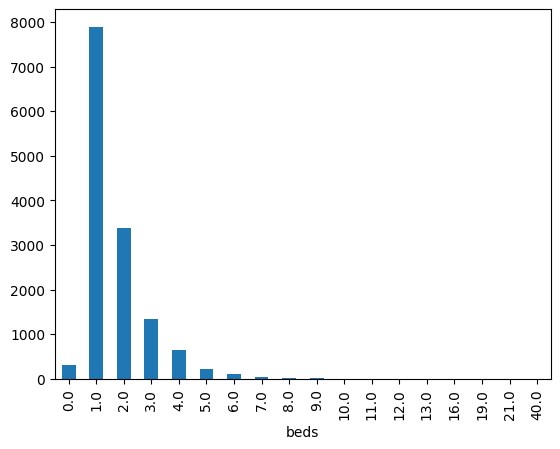

In [249]:
data_formatted['beds'].value_counts().sort_index().plot(kind='bar')

In [250]:
# Imputar valores faltantes de 'beds' con la moda según 'room_type'
data_formatted['beds'] = data_formatted['beds'].fillna(
    data_formatted.groupby('room_type')['beds']
    .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [251]:
# Reemplazar valores 0 en 'beds' con el valor entero de la división entre 'accommodates' y 2
data_formatted['beds'] = data_formatted.apply(
    lambda row: max(1, row['accommodates'] // 2) if row['beds'] == 0 else row['beds'], axis=1
)

Ahora revisemos que sucede con la columna 'bedrooms'

<Axes: xlabel='bedrooms'>

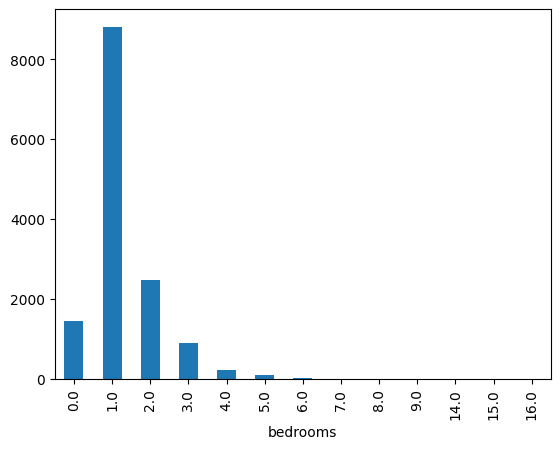

In [252]:
data_formatted['bedrooms'].value_counts().sort_index().plot(kind='bar')

In [253]:
# Imputar valores faltantes de 'bedrooms' con la moda según 'room_type'
data_formatted['bedrooms'] = data_formatted['bedrooms'].fillna(
    data_formatted.groupby('room_type')['bedrooms']
    .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [254]:
# Como no tenemos registros duplicados y ya se realizó la limpieza del dataset podemos proceder a dropear las columnas de id y host_id
data_formatted.drop(['id','host_id'], axis='columns', inplace=True)

In [255]:
data_formatted.info()

<class 'pandas.DataFrame'>
RangeIndex: 14015 entries, 0 to 14014
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                14015 non-null  float64
 1   latitude             14015 non-null  float64
 2   longitude            14015 non-null  float64
 3   room_type            14015 non-null  str    
 4   accommodates         14015 non-null  int64  
 5   bathrooms            14015 non-null  float64
 6   bedrooms             14015 non-null  float64
 7   beds                 14015 non-null  float64
 8   amenities            14015 non-null  str    
 9   review_scores_value  14015 non-null  float64
 10  license              14015 non-null  bool   
 11  instant_bookable     14015 non-null  bool   
dtypes: bool(2), float64(7), int64(1), str(2)
memory usage: 1.1 MB


Vamos a crear una nueva variable que nos indique la distancia mínima en kilometros a alguno de los sitios turisticos de New York City, ya que esto generalmente resulta relevante a la hora de definir los precios para un alojamiento

In [256]:
data_formatted["distance_min"] = data_formatted.apply(lambda row: distancia_minima_turistica(row["latitude"], row["longitude"]), axis=1)

Ahora vamos a procesar las comodidades de los alojamientos

In [257]:
# Normalizamos las comodidades, quitamos símbolos y dejamos todo en minusculas
data = data_formatted.copy()
data['amenities'] = data['amenities'].apply(lambda x: ast.literal_eval(x))
data['amenities'] = data['amenities'].apply(lambda lst: [normalize_amenity(x) for x in lst])
data['amenities']

0        [ethernet connection, self checkin, hot water,...
1        [microwave, hot water, hair dryer, washer, ext...
2        [clothing stora, hot water, hair dryer, extra ...
3        [outdoor furniture, hot water kettle, microwav...
4        [blender, free washer in unit, ethernet connec...
                               ...                        
14010    [hot water kettle, microwave, stainless steel ...
14011    [free washer in unit, hot water kettle, microw...
14012    [hot water kettle, microwave, clothing stora c...
14013    [hot water kettle, microwave, clothing stora c...
14014                   [kitchenette, ethernet connection]
Name: amenities, Length: 14015, dtype: object

Creamos una nueva columna con las comodidades como oración natural agregando "This place offers: " al inicio para realizar el procesamiento con el sentence-transformer.

In [258]:
data["amenities_text"] = data["amenities"].astype(str).apply(format_amenities_to_text)

In [259]:
data["amenities_text"]

0        This place offers: ethernet connection, self c...
1        This place offers: microwave, hot water, hair ...
2        This place offers: clothing stora, hot water, ...
3        This place offers: outdoor furniture, hot wate...
4        This place offers: blender, free washer in uni...
                               ...                        
14010    This place offers: hot water kettle, microwave...
14011    This place offers: free washer in unit, hot wa...
14012    This place offers: hot water kettle, microwave...
14013    This place offers: hot water kettle, microwave...
14014    This place offers: kitchenette, ethernet conne...
Name: amenities_text, Length: 14015, dtype: str

Ahora vamos a realizar la clusterización de las comodidades como texto usando un sentence-transformer que nos mapea las oraciones a un vector de 384 dimensiones, para posteriormente realizar una reducción de dimensionalidad con UMAP y finalmente la clusterización con HDBSCAN.

In [171]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L12-v2")

texts = data["amenities_text"].tolist()

embeddings = model.encode(texts, show_progress_bar=True)

print(embeddings.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3044.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 438/438 [14:38<00:00,  2.01s/it]

(14015, 384)


In [172]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=30,
    random_state=42
)

X_umap = reducer.fit_transform(embeddings)

In [173]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=50)

clusters = clusterer.fit_predict(X_umap)

In [174]:
data["amenity_cluster"] = clusters

<Axes: ylabel='Frequency'>

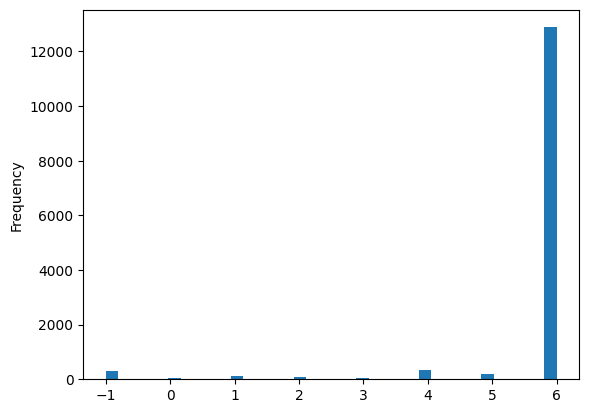

In [175]:
data["amenity_cluster"].plot(kind="hist", bins=36)

Se realiza una clusterización de las comodidades individuales

In [215]:
data["amenities"]

0        [ethernet connection, self checkin, hot water,...
1        [microwave, hot water, hair dryer, washer, ext...
2        [clothing stora, hot water, hair dryer, extra ...
3        [outdoor furniture, hot water kettle, microwav...
4        [blender, free washer in unit, ethernet connec...
                               ...                        
14010    [hot water kettle, microwave, stainless steel ...
14011    [free washer in unit, hot water kettle, microw...
14012    [hot water kettle, microwave, clothing stora c...
14013    [hot water kettle, microwave, clothing stora c...
14014                   [kitchenette, ethernet connection]
Name: amenities, Length: 14015, dtype: object

In [260]:
all_amenities = list(set(
    amenity
    for row in data["amenities"]
    for amenity in row
))

print(f"Total de comodidades únicas: {len(all_amenities)}")

Total de comodidades únicas: 2365


In [261]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L12-v2")

amenity_embeddings = model.encode(all_amenities, show_progress_bar=True)

print(amenity_embeddings.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3461.68it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 74/74 [00:33<00:00,  2.19it/s]

(2365, 384)


In [262]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.05,
    n_components=10,
    random_state=42
)

X_umap = reducer.fit_transform(amenity_embeddings)

In [263]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=20)

amenity_clusters = clusterer.fit_predict(X_umap)

In [264]:
amenity_cluster_map = dict(zip(all_amenities,  amenity_clusters))

In [265]:
cluster_counts = pd.Series(amenity_clusters).value_counts().sort_index()

print(cluster_counts)

-1      33
 0     206
 1      51
 2     443
 3     665
 4     192
 5      43
 6     383
 7      25
 8      25
 9      31
 10     42
 11     43
 12    183
Name: count, dtype: int64


In [266]:
cluster_df = pd.DataFrame({
    "amenity": all_amenities,
    "cluster": amenity_clusters
})

for c in sorted(cluster_df["cluster"].unique()):

    if c == -1:
        continue

    print(f"\nCluster {c}")

    print(
        cluster_df[
            cluster_df["cluster"] == c
        ]["amenity"].head(10).tolist()
    )


Cluster 0
['surround dolby atmos sound system bluetooth and aux', 'high end sound system tv sound system', 'neva sound system', 'tv dvd player streaming', 'klipsch sound system bluetooth and aux', 'edison sound system', 'onkyo sound system aux', 'alexa music unlimited sound system', 'record player includes bluetooth speaker sound system bluetooth and aux', 'megaboom bluetooth speaker sound system aux']

Cluster 1
['coffee maker drip coffee maker espresso machine french press nespresso', 'coffee maker drip coffee maker espresso machine keurig coffee machine', 'coffee maker french press pourover coffee', 'coffee maker espresso machine french press nespresso pourover coffee', 'coffee maker nespresso pourover coffee', 'coffee maker drip coffee maker french press nespresso pourover coffee', 'coffee maker drip coffee maker keurig coffee machine pourover coffee', 'coffee maker espresso machine nespresso pourover coffee', 'coffee maker drip coffee maker french press keurig coffee machine', 'c

Se definen algunas de las palabras más frecuentes que se van a encontrar en las comodidades de los alojamientos y se agrupan de la siguiente forma

In [33]:
patterns_initial = {
    'essentials' : r'wifi|internet|heater|heating|radiator|furnace|air.?conditioning|ac\b|hot water|kitchen|stove|oven|microwave|refrigerator|cook|fridge|dishwasher|coffee maker|toaster|fire alarm|smoke alarm|fire extinguisher|carbon monoxide',
    'luxurious' : r'pool|swim|gym|fitness|exercise equipment|sound system|stereo|speaker',
    'tv': r'\btv\b|hdtv|netflix|roku|smart tv|flat.?screen|cable|apple tv|chromecast|prime video',
    'parking': r'parking|garage',
    'washer': r'washer|laundry|washing machine',
    'dryer': r'\bdryer\b(?! hair)',
    'hair_dryer': r'hair dryer',
    'cleaning_products': r'cleaning product|detergent|soap|shampoo|conditioner|body wash',
}

In [34]:
patterns = {
    'kitchen': r'kitchen|stove|oven|microwave|refrigerator|fridge|dishwasher|coffee maker|toaster|cookware|kettle',
    'climate': r'heater|heating|radiator|furnace|air.?conditioning|\bac\b|fan',
    'wifi': r'wifi|internet|ethernet',
    'luxurious' : r'pool|swim|gym|fitness|exercise equipment|sound system|stereo|speaker|hot tub|jacuzzi|spa|sauna|home theater|game room|piano',
    'tv': r'\btv\b|hdtv|smart tv|flat.?screen|netflix|roku|apple tv|chromecast|prime video|disney|cable',
    'parking': r'parking|garage|carport|free parking',
    'washer': r'washer|laundry|washing machine',
    'dryer': r'\bdryer\b(?! hair)',
    'hair_dryer': r'hair dryer',
    'cleaning_products': r'cleaning product|detergent|soap|shampoo|conditioner|body wash|towels|linens|bed sheets',
    'workspace': r'workspace|desk|office|laptop friendly|work desk',
    'balcony_view': r'balcony|patio|terrace|deck|garden|yard|view|sea view|mountain view|city view',
    'family': r'crib|high chair|baby bath|children|kids|toys|books for children',
    'pet_friendly': r'pet|pets allowed',
    'security': r'lock|safe|security camera|alarm system',
    'accessibility': r'wheelchair|accessible|elevator|lift',
    'outdoor': r'bbq|barbecue|grill|fire pit|outdoor furniture',
    'entertainment': r'game|console|xbox|playstation|board games',
}

In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14015 entries, 0 to 14014
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                14015 non-null  float64
 1   latitude             14015 non-null  float64
 2   longitude            14015 non-null  float64
 3   room_type            14015 non-null  str    
 4   accommodates         14015 non-null  int64  
 5   bathrooms            14015 non-null  float64
 6   bedrooms             14015 non-null  float64
 7   beds                 14015 non-null  float64
 8   amenities            14015 non-null  object 
 9   review_scores_value  14015 non-null  float64
 10  license              14015 non-null  bool   
 11  instant_bookable     14015 non-null  bool   
dtypes: bool(2), float64(7), int64(1), object(1), str(1)
memory usage: 1.1+ MB


In [36]:
# Se agrupan las amenidades
data['amenities_grouped'] = data['amenities'].apply(map_amenities)

# Unir todas las listas en una sola
amenities_flat = [amenity for sublist in data['amenities_grouped'] for amenity in sublist]

# Contar frecuencia
counter = Counter(amenities_flat)

print("Frecuencia de amenidades agrupadas:")
for amenity, freq in counter.most_common():
    print(f"{amenity}: {freq}")

Frecuencia de amenidades agrupadas:
wifi: 13912
climate: 13906
kitchen: 13646
cleaning_products: 12142
dryer: 11767
tv: 11713
hair_dryer: 10777
luxurious: 9850
security: 9795
parking: 9222
workspace: 8933
washer: 7133
balcony_view: 4635
pet_friendly: 3573
accessibility: 2913
outdoor: 2619
family: 2613
entertainment: 1355


In [37]:
# Se crea una columna dummy por cada amenidad agrupada
for a,_ in counter.items():
    data[f'amenity_{a}'] = data['amenities_grouped'].apply(lambda x: a in x) # Devuelve True o False

También se creará una nueva variable con la cantidad de amenidades

In [38]:
data["amenities_count"] = data["amenities"].apply(len)

In [39]:
# Eliminar las columnas que más del 90% de los registros tienen esa amenidad y se pueden considerar esenciales
data.drop(['amenity_wifi', 'amenity_climate', 'amenity_kitchen'], axis='columns', inplace=True)

In [40]:
# Eliminar las columnas auxiliares o que ya no se utilizarán y la de esenciales ya que practicamente todos los registros tienen esa amenidad
#data.drop(['amenities', 'amenities_grouped', 'amenity_essentials'], axis='columns', inplace=True)

## 5. Visualización de datos

### Variable de salida

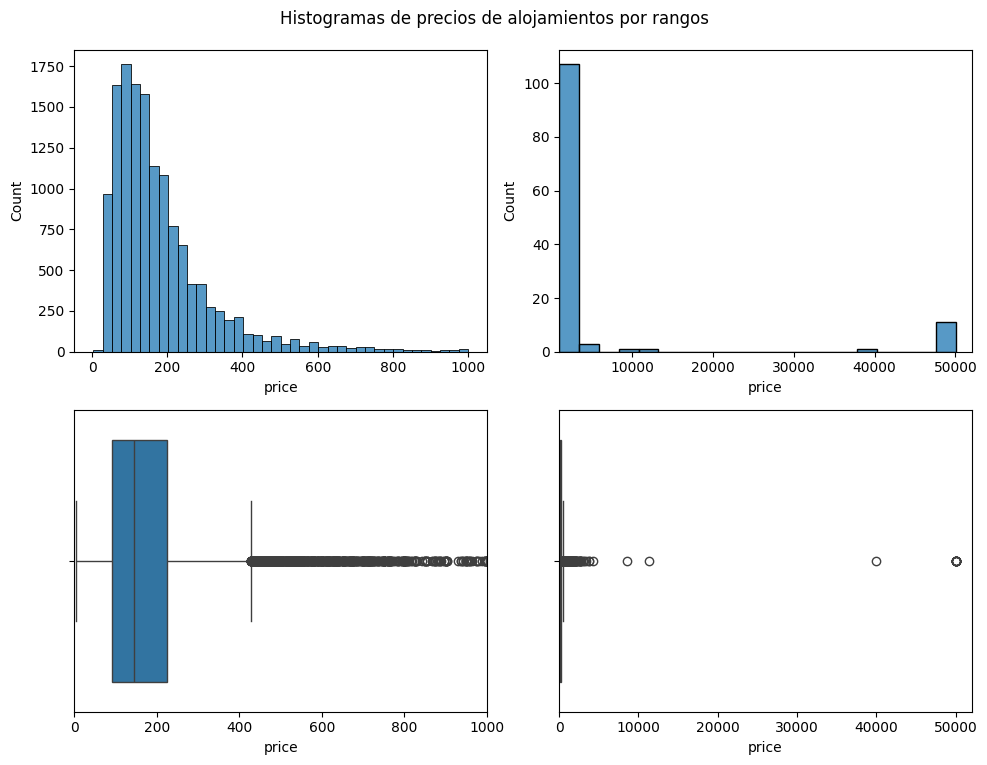

In [42]:
# Histogramas y boxplots de precios por rangos
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axs = axs.flatten()

sns.histplot(data[data['price'] <= 1000]['price'], bins=40, ax=axs[0])

sns.histplot(data[data['price'] > 1000]['price'], bins=20, ax=axs[1])
axs[1].set_xlim(1000, 52000)  # limitar escala para ver mejor

sns.boxplot(x=data['price'], ax=axs[2])
axs[2].set_xlim(0, 1000)  # limitar escala para ver mejor

sns.boxplot(x=data['price'], ax=axs[3])
axs[3].set_xlim(0, 52000)  # limitar escala para ver mejor

fig.suptitle('Histogramas de precios de alojamientos por rangos')
plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Ajustar el rectangulo para dejar espacio al suptitle
plt.show()

Calculo de valores atípicos

In [43]:
#Calculo de Q1 t Q3
Q1 = np.percentile(data['price'], 25, method = 'midpoint')
Q3 = np.percentile(data['price'], 75, method = 'midpoint')

#Cálculo del rango intercuartil
IQR = Q3 - Q1

#Cálculo de valor mínimo y máximo para los valores atípicos
VAInf = Q1 - 1.5*IQR
VASup = Q3 + 1.5*IQR

print(f'Valor atípico leve inferior:{VAInf}')
print(f'Valor atípico leve superior:{VASup}')

Valor atípico leve inferior:-112.5
Valor atípico leve superior:427.5


In [44]:
data[data['price']>VASup].shape

(902, 30)

In [45]:
# Se eliminan los valores atípicos de la variable objetivo
data = data.drop(data[data['price']>VASup].index)

#Reiniciar el indice
data.reset_index(drop=True, inplace=True)

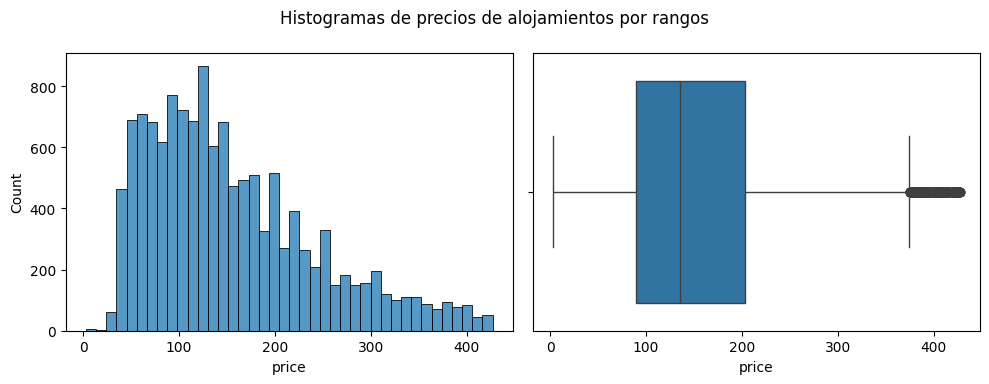

In [46]:
# Histogramas y boxplots de precios por rangos
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axs = axs.flatten()

sns.histplot(data['price'], bins=40, ax=axs[0])

sns.boxplot(x=data['price'], ax=axs[1])

fig.suptitle('Histogramas de precios de alojamientos por rangos')
plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Ajustar el rectangulo para dejar espacio al suptitle
plt.show()

### Variables entrada

In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13113 entries, 0 to 13112
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      13113 non-null  float64
 1   latitude                   13113 non-null  float64
 2   longitude                  13113 non-null  float64
 3   room_type                  13113 non-null  str    
 4   accommodates               13113 non-null  int64  
 5   bathrooms                  13113 non-null  float64
 6   bedrooms                   13113 non-null  float64
 7   beds                       13113 non-null  float64
 8   amenities                  13113 non-null  object 
 9   review_scores_value        13113 non-null  float64
 10  license                    13113 non-null  bool   
 11  instant_bookable           13113 non-null  bool   
 12  amenities_grouped          13113 non-null  object 
 13  amenity_parking            13113 non-null  bool   
 14  a

In [48]:
#Lista de variables categóricas
catCols = data.select_dtypes(include = ["str", 'bool']).columns.tolist()

#Lista de variables numéricas
numCols = data.select_dtypes(include = ['float64','int64']).columns.tolist()

# Se dropean la variable objetivo
numCols.remove('price')

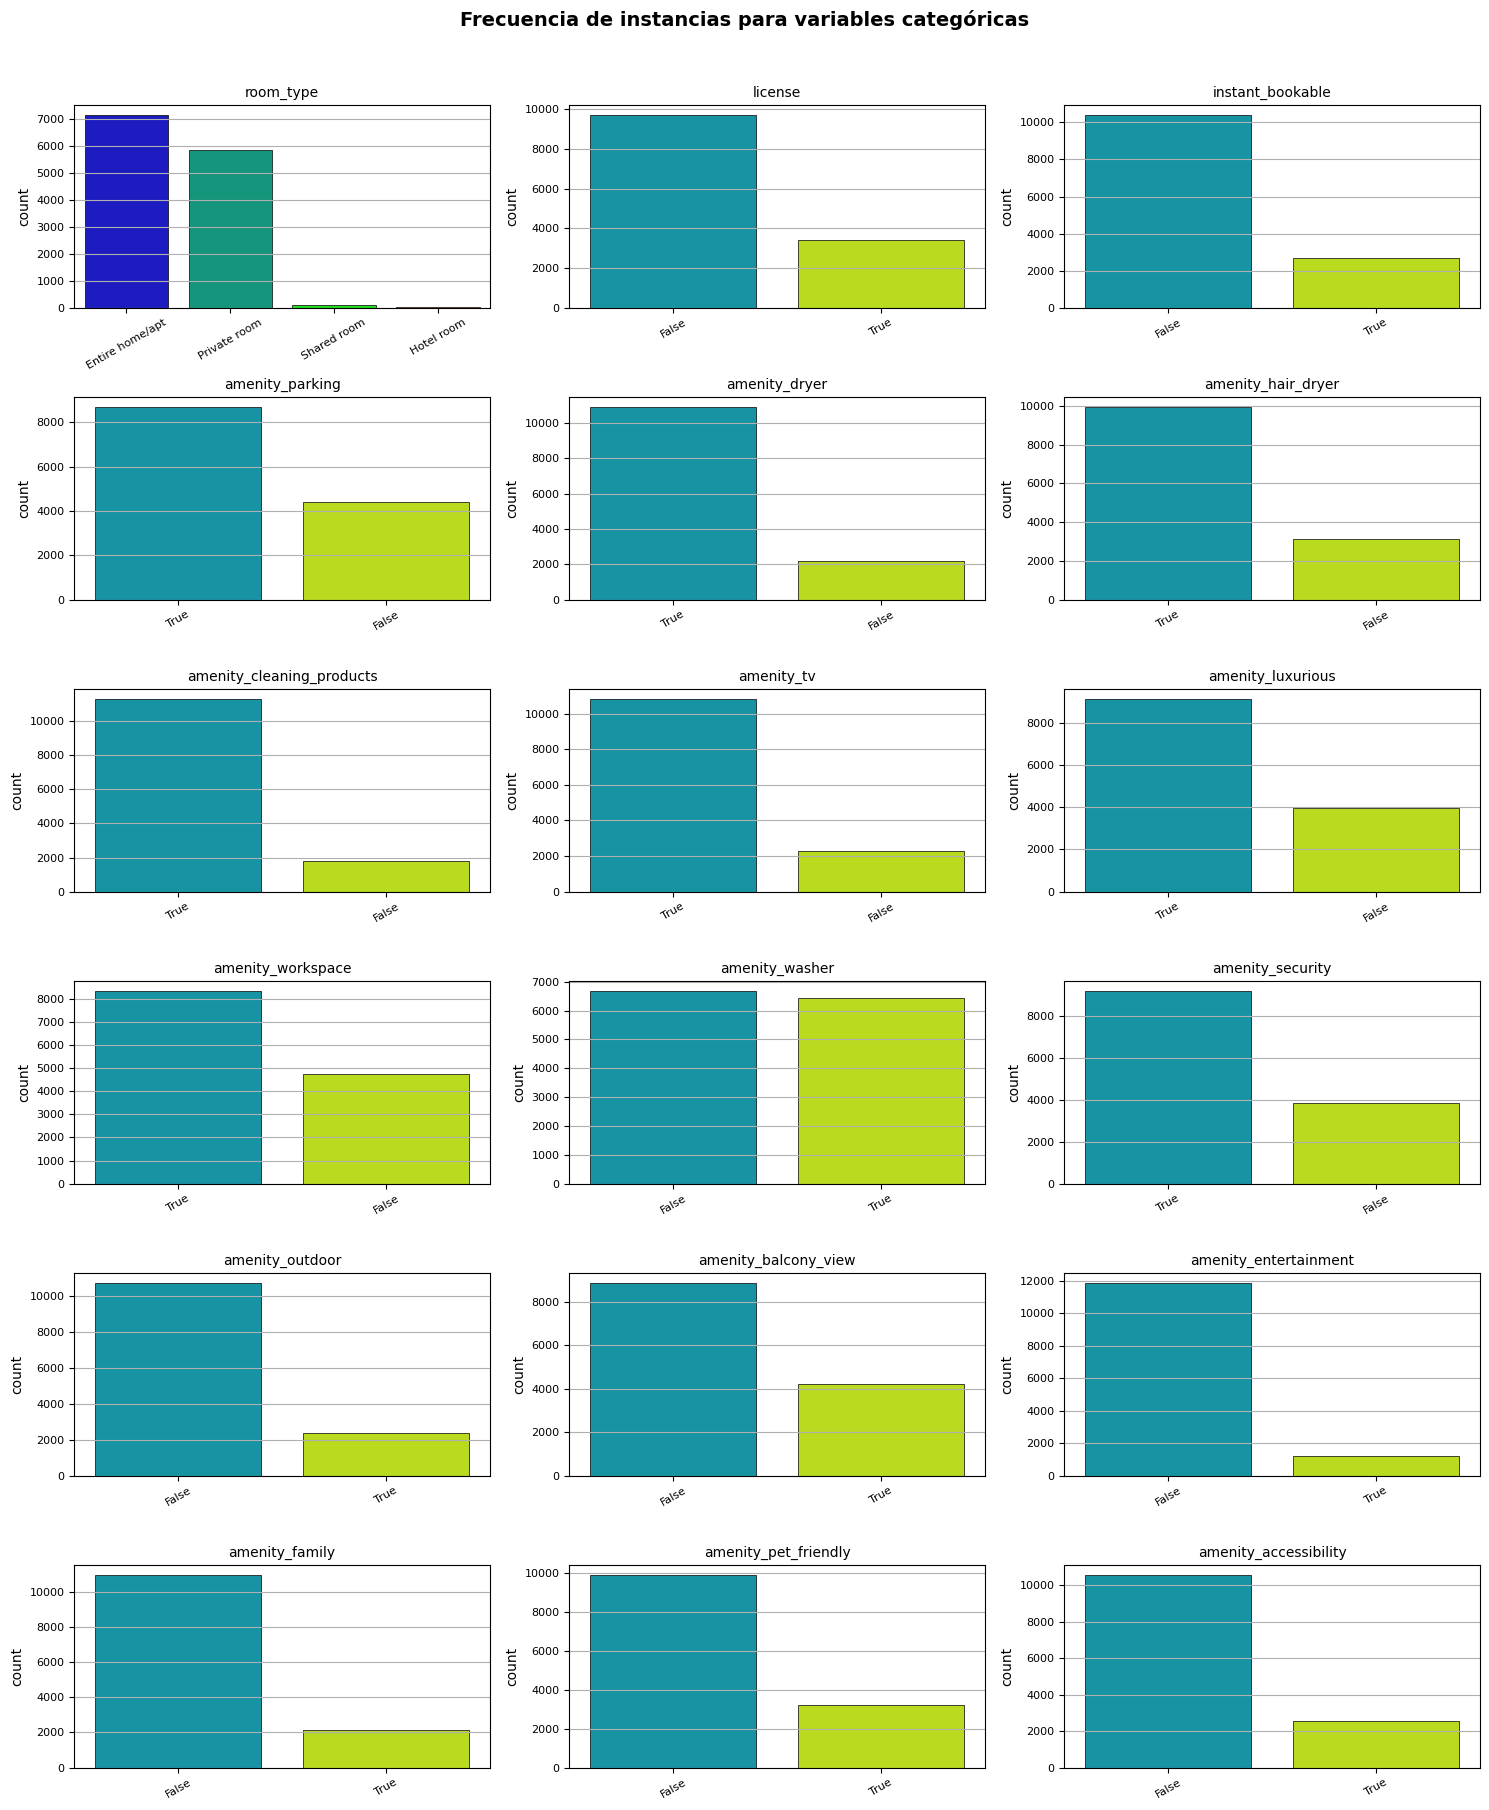

In [49]:
#Visualización de frecuencia de instancias para variables categóricas
multiple_plot(3, data , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

Para 'room_type' hay una poca cantidad de shared_room y hotel_room por lo que se dropearan estos registros y la variable se transformará en una booleana para identificar si es un apartamento completo o habitación privada

In [50]:
# Dropear del dataframe los 'Shared room' y 'Hotel room'
data = data[~data['room_type'].isin(['Shared room', 'Hotel room'])]
data.reset_index(drop=True, inplace=True)

In [51]:
# Renombrar 'room_type' a 'is_entire_home' como booleana
data['is_entire_home'] = data['room_type'].map({'Entire home/apt': True, 'Private room': False})

# Dropear la columna original
data.drop(['room_type'], axis='columns', inplace=True)

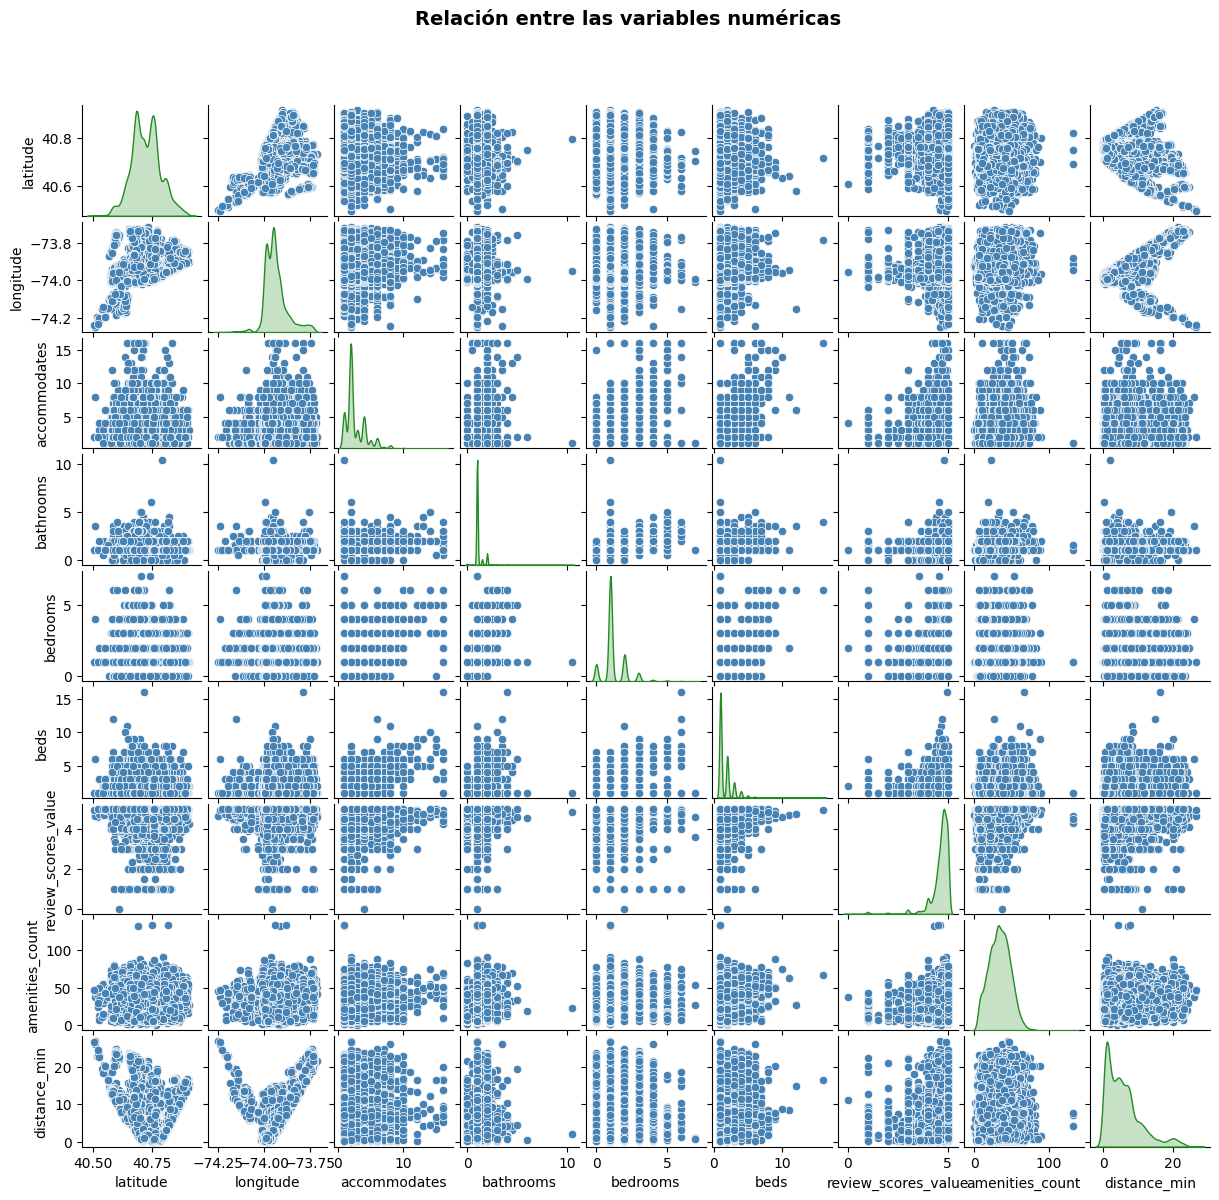

In [52]:
# Visualización de variables numéricas relacionada al host
multiple_plot(1, data , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

Como observamos en las diferentes gráficas tenemos algunos outliers y una buena dispersión entre los datos. 

La relación entre las coordenadas y la distancia mínima como era de esperarse presentan un patron.

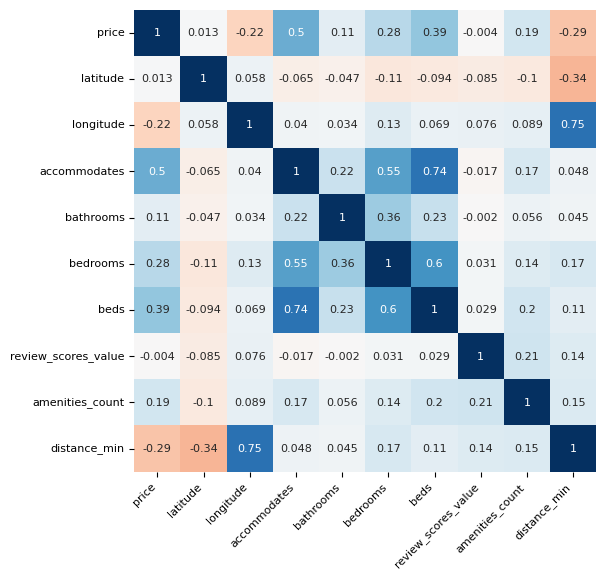

In [53]:
# Calculamos la correlación entre las variables númericas y el precio
matrizCorr = data[['price']+numCols].corr()
# Mapa de calor (Heatmap) de la matriz de correlaciones

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

sns.heatmap(
    matrizCorr,
    annot     = True,
    cbar      = False,
    annot_kws = {"size": 8},
    vmin      = -1,
    vmax      = 1,
    center    = 0,
    cmap      = 'RdBu',
    square    = True,
    ax        = ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    horizontalalignment = 'right',
)


ax.tick_params(labelsize = 8)

## 6. Preparación de los datos

#### Valores atípicos para las variables de entrada

In [54]:
# Utilización de LocalOutlierFactor con 6 vecinos para identificar valores atípicos en las variables de entrada

# Crear un objeto LocalOutlierFactor con n_neighbors=6
lof = LocalOutlierFactor(n_neighbors=6, contamination=0.1)

# Identificar los valores atípicos por medio de lof
y_pred = lof.fit_predict(data[numCols])

# Identificar los índices de los valores atípicos
outliers = y_pred == -1

print('Indices de valores atípicos: ', data[outliers].index.tolist())
print(len(data[outliers]))

Indices de valores atípicos:  [0, 1, 2, 4, 27, 31, 35, 58, 66, 67, 69, 78, 95, 100, 101, 108, 112, 132, 137, 143, 148, 150, 159, 167, 188, 192, 195, 204, 208, 216, 218, 219, 235, 239, 257, 268, 280, 312, 335, 341, 346, 351, 366, 382, 403, 417, 424, 427, 431, 445, 447, 448, 456, 458, 462, 463, 471, 476, 486, 492, 495, 527, 535, 543, 558, 563, 570, 576, 583, 593, 605, 612, 616, 625, 633, 637, 647, 650, 652, 679, 687, 689, 694, 702, 703, 707, 715, 723, 726, 731, 737, 745, 748, 760, 770, 784, 793, 800, 801, 819, 820, 823, 845, 870, 871, 877, 880, 881, 890, 902, 907, 909, 911, 913, 921, 930, 947, 958, 960, 966, 972, 1007, 1029, 1032, 1045, 1073, 1085, 1086, 1089, 1115, 1122, 1125, 1142, 1171, 1172, 1179, 1190, 1204, 1221, 1223, 1227, 1232, 1239, 1250, 1252, 1265, 1277, 1279, 1299, 1310, 1317, 1319, 1350, 1351, 1361, 1363, 1382, 1383, 1386, 1397, 1400, 1417, 1418, 1420, 1433, 1434, 1451, 1454, 1463, 1475, 1480, 1484, 1494, 1498, 1516, 1524, 1549, 1552, 1577, 1580, 1583, 1592, 1606, 1608, 162

In [55]:
# Creamos un nuevo dataframe sin outliers
data_sin_outliers = data[~outliers]
data_sin_outliers.reset_index(drop=True, inplace=True)

## 7. Exportar el dataset

In [56]:
# Exportamos el dataframe a un archivo CSV
data_sin_outliers.to_csv(DATASET_PATH + 'Airbnb_NY_cleaned.csv', index=False)

## 8. Preparación de la data para el modelo

In [57]:
data_cleaned = pd.read_csv(DATASET_PATH + 'Airbnb_NY_cleaned.csv')

### Preparación de variable objetivo
Se aplica una transformación logaritmica al precio (variable objetivo). Esto reduce la influencia de outliers y mejora el ajuste para relaciones multiplicativas (típicas en precios)

In [58]:
data_cleaned['price'] = np.log(data_cleaned['price'])

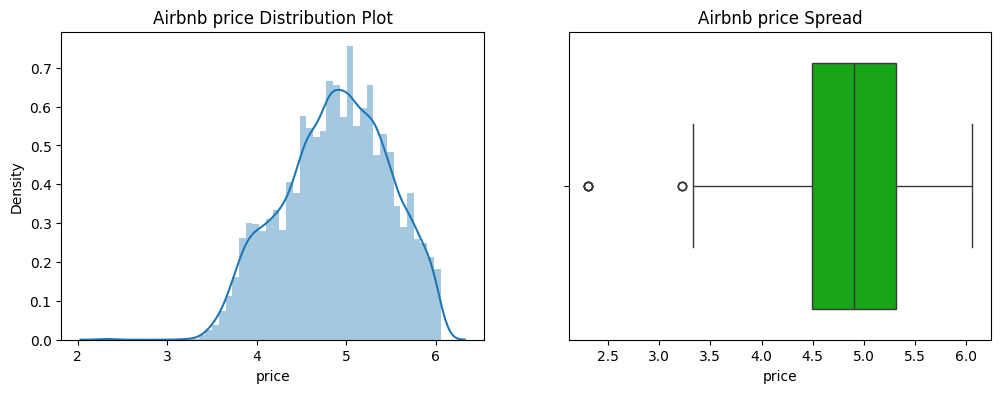

In [59]:
data = data_cleaned.copy()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Airbnb price Distribution Plot')
sns.distplot(data.price)

plt.subplot(1,2,2)
plt.title('Airbnb price Spread')
sns.boxplot(x=data.price, palette='nipy_spectral')

plt.show()

In [60]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

X = data.drop(columns = ["price","amenities","amenities_grouped"])
y = data['price']

Obtenemos los datos de entrenamiento y prueba para los modelos iniciales

In [61]:
#En este caso, el 80% de los datos se utilizarán para entrenar el modelo.
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

#Escalar las variables de entrada
num_vars = X.select_dtypes(include=['number']).columns.tolist()
print("Columnas Numéricas:{}".format(num_vars))

scaler = StandardScaler()

X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars]  = scaler.transform(X_test[num_vars])

Columnas Numéricas:['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_value', 'amenities_count', 'distance_min']


Obtenemos los datos completos para los tunnings de los modelos y el escalado en producción

In [62]:
# Nuevamente se asigna a 'X_Completo' y 'y_Completo' los datos entrada y salida respectivamente
X_Completo = X
y_Completo = y

# Se escalan los datos numéricos de entrada
X_Completo[num_vars] = scaler.fit_transform(X_Completo[num_vars])

# Se guarda el scaler
#joblib.dump(scaler, '../modelos/scaler/StandarScalerFull_Airbnb_V1.pkl')

## 9. Validación de modelos

In [63]:
# Diccionario para almacenar los resultados de los modelos
resultados_modelos = {}

### 9.1 MLP

In [64]:
model_mlp = Sequential([
    Dense(32, activation="relu", input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(1)
])

model_mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [65]:
history_mlp = model_mlp.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/50
249/249 - 1s - 4ms/step - loss: 4.1767 - mae: 1.5521 - val_loss: 0.4934 - val_mae: 0.5361
Epoch 2/50
249/249 - 0s - 660us/step - loss: 0.9690 - mae: 0.7851 - val_loss: 0.3433 - val_mae: 0.4551
Epoch 3/50
249/249 - 0s - 613us/step - loss: 0.7268 - mae: 0.6745 - val_loss: 0.2900 - val_mae: 0.4198
Epoch 4/50
249/249 - 0s - 600us/step - loss: 0.5934 - mae: 0.6112 - val_loss: 0.2813 - val_mae: 0.4171
Epoch 5/50
249/249 - 0s - 858us/step - loss: 0.4882 - mae: 0.5530 - val_loss: 0.2314 - val_mae: 0.3749
Epoch 6/50
249/249 - 0s - 665us/step - loss: 0.3987 - mae: 0.5003 - val_loss: 0.2600 - val_mae: 0.4022
Epoch 7/50
249/249 - 0s - 692us/step - loss: 0.3371 - mae: 0.4555 - val_loss: 0.2305 - val_mae: 0.3784
Epoch 8/50
249/249 - 0s - 891us/step - loss: 0.2855 - mae: 0.4194 - val_loss: 0.2473 - val_mae: 0.3954
Epoch 9/50
249/249 - 0s - 682us/step - loss: 0.2535 - mae: 0.3954 - val_loss: 0.2296 - val_mae: 0.3792
Epoch 10/50
249/249 - 0s - 711us/step - loss: 0.2226 - mae: 0.3705 - val_lo

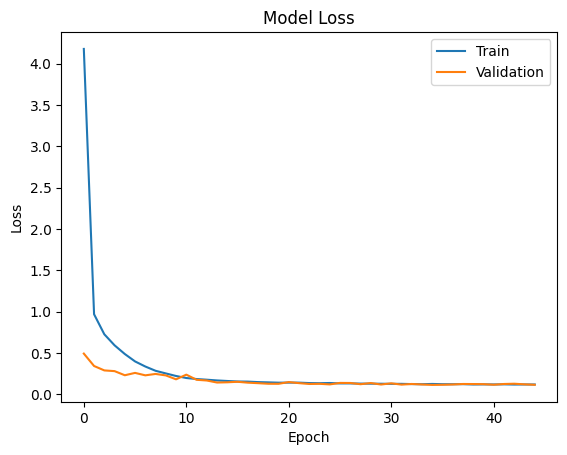

In [66]:
plt.plot(history_mlp.history["loss"])
plt.plot(history_mlp.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [67]:
test_loss, test_mae = model_mlp.evaluate(
    X_test,
    y_test
)

print("Test MAE:", test_mae)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - loss: 0.1269 - mae: 0.2775
Test MAE: 0.27753114700317383


In [68]:
y_pred_log = model_mlp.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_real = np.expm1(y_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step


In [69]:
r2 = r2_score(y_real, y_pred)

print("R²:", r2)

R²: 0.5421156502637163


### 9.2 Embeddings

In [70]:
data["amenities_text"] = data["amenities"].apply(ast.literal_eval).apply(
    lambda x: " ".join(x)
)

In [71]:
data["amenities_text"]

0        outdoor furniture hot water kettle microwave s...
1        barbecue utensils outdoor furniture hot water ...
2        hot water kettle microwave 13 inch hdtv with s...
3        microwave hot water lock on bedroom door hair ...
4        microwave self checkin hot water lock on bedro...
                               ...                        
11707    first aid kit wifi tv smoke alarm kitchen carb...
11708    first aid kit wifi tv smoke alarm carbon monox...
11709    first aid kit wifi tv smoke alarm carbon monox...
11710    free washer in unit hot water kettle microwave...
11711    hot water kettle microwave clothing storage cl...
Name: amenities_text, Length: 11712, dtype: str

In [73]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L12-v2"
)

texts = data["amenities_text"].tolist()

embeddings = model.encode(
    texts,
    show_progress_bar=True
)

print(embeddings.shape)

Batches: 100%|██████████| 366/366 [00:37<00:00,  9.77it/s]

(11712, 384)


In [75]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=50,
    random_state=42
)

X_umap = reducer.fit_transform(
    embeddings
)

In [76]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50
)

clusters = clusterer.fit_predict(
    X_umap
)

data["amenity_cluster"] = clusters

<Axes: ylabel='Frequency'>

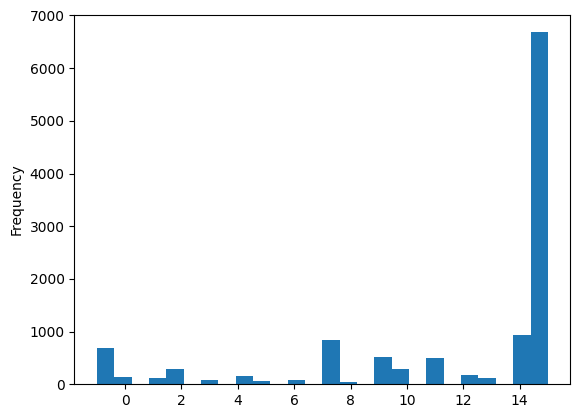

In [77]:
data["amenity_cluster"].plot(kind="hist", bins=26)

Clusterización de amenities individuales

In [78]:
all_amenities = list(set(
    amenity
    for row in data["amenities"].apply(ast.literal_eval)
    for amenity in row
))

In [79]:
len(all_amenities)

4311

In [80]:
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L12-v2"
)

amenity_embeddings = model.encode(
    all_amenities,
    show_progress_bar=True
)

print(amenity_embeddings.shape)

Batches: 100%|██████████| 135/135 [00:05<00:00, 23.86it/s]

(4311, 384)


In [81]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.05,
    n_components=10,
    random_state=42
)

X_umap = reducer.fit_transform(
    amenity_embeddings
)

In [82]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20
)

amenity_clusters = clusterer.fit_predict(
    X_umap
)

In [83]:
amenity_cluster_map = dict(zip(
    all_amenities,
    amenity_clusters
))

In [84]:
cluster_counts = pd.Series(
    amenity_clusters
).value_counts().sort_index()

print(cluster_counts)

-1     483
 0     176
 1      45
 2      74
 3      71
 4      56
 5      90
 6      50
 7      40
 8     358
 9      41
 10    391
 11     26
 12     22
 13    588
 14    264
 15     34
 16     37
 17    186
 18    109
 19    173
 20     32
 21     94
 22     23
 23    191
 24     37
 25     82
 26     28
 27     43
 28     27
 29     28
 30     53
 31     34
 32    196
 33     44
 34     34
 35     51
Name: count, dtype: int64


In [85]:
cluster_df = pd.DataFrame({
    "amenity": all_amenities,
    "cluster": amenity_clusters
})

for c in sorted(cluster_df["cluster"].unique()):

    if c == -1:
        continue

    print(f"\nCluster {c}")

    print(
        cluster_df[
            cluster_df["cluster"] == c
        ]["amenity"].head(10).tolist()
    )


Cluster 0
['bose portable speaker bluetooth sound system', 'bose bluetooth sound system', 'google home speakers bluetooth sound system', 'jbl sound system with bluetooth and aux', 'vizio surround sound system bluetooth sound system', 'projector in the living space bluetooth sound system', 'blue tooth speaker bluetooth sound system', 'bose sound system with aux', 'samsung 71 surround dolby atmos sound system with bluetooth and aux', 'akai sound system']

Cluster 1
['fast wifi 486 mbps', 'fast wifi 436 mbps', 'fast wifi 473 mbps', 'fast wifi 446 mbps', 'fast wifi 466 mbps', 'fast wifi 489 mbps', 'fast wifi 442 mbps', 'fast wifi 468 mbps', 'fast wifi 434 mbps', 'fast wifi 458 mbps']

Cluster 2
['40 inch hdtv with roku', '30 inch tv with roku', '32 inch hdtv with chromecast roku', '42 inch hdtv with chromecast', '70 inch hdtv with roku', '35 inch hdtv with roku', '55 inch hdtv with chromecast premium cable', '96 inch tv with roku', '39 inch tv with roku', '58 inch hdtv with roku']

Cluste

In [ ]:
# Agregamos los 36 clusters a el dataset de entranamiento como variables booleanas.

for c in sorted(cluster_df["cluster"].unique()):

    if c == -1:
        continue

    amenities_in_cluster = set(
        cluster_df[cluster_df["cluster"] == c]["amenity"]
    )

    data[f"cluster_{c}"] = data["amenities"].apply(
        lambda x: any(
            amenity in amenities_in_cluster
            for amenity in ast.literal_eval(x)
        )
    )

In [101]:
X_Completo = data[['latitude','longitude','accommodates','bathrooms','bedrooms','beds','review_scores_value','license','instant_bookable','distance_min','is_entire_home','cluster_0','cluster_1','cluster_2','cluster_3','cluster_4','cluster_5','cluster_6','cluster_7','cluster_8','cluster_9','cluster_10','cluster_11','cluster_12','cluster_13','cluster_14','cluster_15','cluster_16','cluster_17','cluster_18','cluster_19','cluster_20','cluster_21','cluster_22','cluster_23','cluster_24','cluster_25','cluster_26','cluster_27','cluster_28','cluster_29','cluster_30','cluster_31','cluster_32','cluster_33','cluster_34','cluster_35']]
Y_Completo = data['price']

In [105]:
def split_data(X, y, test_size=0.2, random_state=1234):
    #En este caso, el 80% de los datos se utilizarán para entrenar el modelo.
    X_train, X_test, y_train, y_test = train_test_split(
                                            X,
                                            y.values.reshape(-1,1),
                                            train_size   = 0.8,
                                            random_state = 1234,
                                            shuffle      = True
                                        )

    #Escalar las variables de entrada
    num_vars = X.select_dtypes(include=['number']).columns.tolist()
    print("Columnas Numéricas:{}".format(num_vars))

    scaler = StandardScaler()

    X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
    X_test[num_vars]  = scaler.transform(X_test[num_vars])

    return X_train, X_test, y_train, y_test, scaler

def crear_modelo_mlp(input_shape):
    model = Sequential([
        Dense(32, activation="relu", input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def entrenar_modelo( X_train, y_train, model, nombre_modelo):
    history_mlp = model.fit(
                                X_train,
                                y_train,
                                validation_split=0.15,
                                epochs=50,
                                batch_size=32,
                                callbacks=[early_stop],
                                verbose=2
                                )
    print(f"{nombre_modelo} entrenado.")

    plt.plot(history_mlp.history["loss"])
    plt.plot(history_mlp.history["val_loss"])
    plt.title("Model Loss - " + nombre_modelo)
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"])
    plt.show()

    return history_mlp

def evaluar_modelo(modelo, X_test, y_test, nombre_modelo):
    y_pred_log = modelo.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_real = np.expm1(y_test)
    r2 = r2_score(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    print(f"{nombre_modelo} - R²: {r2:.4f}, MAE: {mae:.4f}, MSE: {mse:.4f}")

Columnas Numéricas:['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_value', 'distance_min']
Epoch 1/50
249/249 - 1s - 4ms/step - loss: 3.1343 - mae: 1.3207 - val_loss: 0.4680 - val_mae: 0.5237
Epoch 2/50
249/249 - 0s - 695us/step - loss: 0.8030 - mae: 0.7068 - val_loss: 0.4396 - val_mae: 0.5443
Epoch 3/50
249/249 - 0s - 633us/step - loss: 0.4887 - mae: 0.5516 - val_loss: 0.3644 - val_mae: 0.5027
Epoch 4/50
249/249 - 0s - 670us/step - loss: 0.3183 - mae: 0.4433 - val_loss: 0.2848 - val_mae: 0.4343
Epoch 5/50
249/249 - 0s - 664us/step - loss: 0.2369 - mae: 0.3835 - val_loss: 0.2030 - val_mae: 0.3599
Epoch 6/50
249/249 - 0s - 638us/step - loss: 0.2028 - mae: 0.3552 - val_loss: 0.1707 - val_mae: 0.3297
Epoch 7/50
249/249 - 0s - 686us/step - loss: 0.1846 - mae: 0.3408 - val_loss: 0.1452 - val_mae: 0.3003
Epoch 8/50
249/249 - 0s - 653us/step - loss: 0.1682 - mae: 0.3243 - val_loss: 0.1626 - val_mae: 0.3174
Epoch 9/50
249/249 - 0s - 636us/step - loss: 

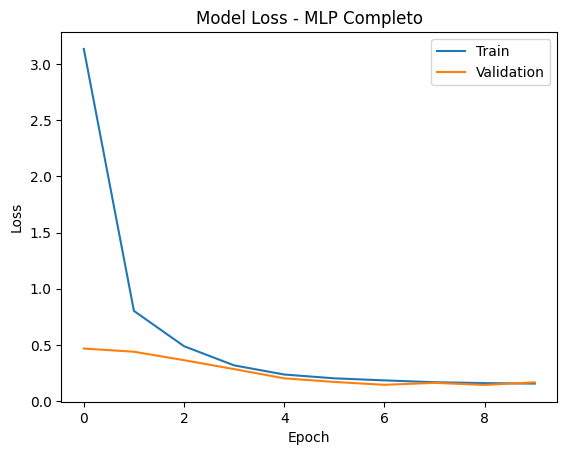

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step
MLP Completo - R²: -2.2403, MAE: 75.7923, MSE: 26713.6393


In [106]:
# Entrenamiento y evaluación del modelo MLP con el dataset completo
X_train, X_test, y_train, y_test, scaler = split_data(X_Completo, Y_Completo)
model_mlp = crear_modelo_mlp(X_train.shape[1])
history_mlp = entrenar_modelo(X_train, y_train, model_mlp,  "MLP Completo")
evaluar_modelo(model_mlp, X_test, y_test, "MLP Completo")

Dada las metricas actuales, vamos a reducir la cantidad de clusters, haciendo un post-procesamiento de las amenities, para reducir informacion redundantes. 

In [114]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 11712 entries, 0 to 11711
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      11712 non-null  float64
 1   latitude                   11712 non-null  float64
 2   longitude                  11712 non-null  float64
 3   accommodates               11712 non-null  int64  
 4   bathrooms                  11712 non-null  float64
 5   bedrooms                   11712 non-null  float64
 6   beds                       11712 non-null  float64
 7   amenities                  11712 non-null  str    
 8   review_scores_value        11712 non-null  float64
 9   license                    11712 non-null  bool   
 10  instant_bookable           11712 non-null  bool   
 11  amenities_grouped          11712 non-null  str    
 12  amenity_parking            11712 non-null  bool   
 13  amenity_dryer              11712 non-null  bool   
 14  a

Batches: 100%|██████████| 366/366 [00:34<00:00, 10.69it/s]


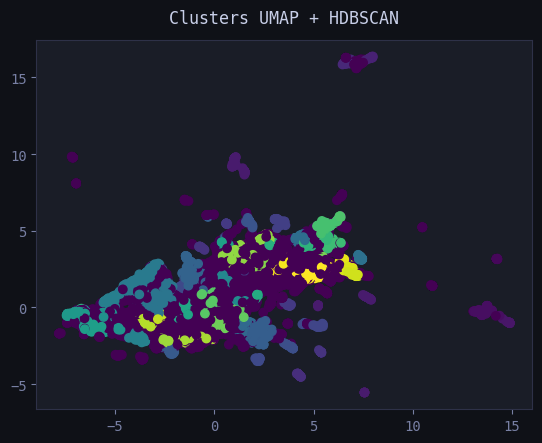


🔎 Ejemplos por cluster:


Cluster 0:
- ['hot water', 'elevator', 'wifi', 'kitchen', 'fire extinguisher', 'smoke alarm', 'tv with standard cable', 'dedicated workspace', 'heating', 'air conditioning', 'carbon monoxide alarm']
- ['hot water', 'wifi', 'tv', 'dedicated workspace', 'smoke alarm', 'kitchen', 'air conditioning', 'carbon monoxide alarm']
- ['hot water', 'wifi', 'kitchen', 'hangers', 'dedicated workspace', 'smoke alarm', 'heating', 'refrigerator', 'carbon monoxide alarm']
- ['hot water', 'wifi', 'tv', 'kitchen', 'hangers', 'dedicated workspace', 'smoke alarm', 'heating', 'carbon monoxide alarm']
- ['hot water', 'wifi', 'kitchen', 'iron', 'hangers', 'dedicated workspace', 'smoke alarm', 'heating', 'carbon monoxide alarm']

Cluster 1:
- ['wifi', 'kitchen', 'hangers', 'hot tub', 'smoke alarm', 'heating', 'air conditioning', 'carbon monoxide alarm']
- ['hot water', 'wifi', 'tv', 'kitchen', 'hangers', 'smoke alarm', 'heating', 'carbon monoxide alarm']
- ['wifi', 'kitchen', 'hangers

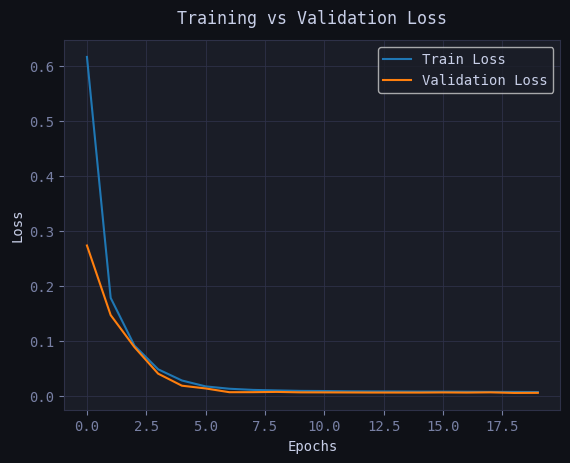

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step

📊 Resultados del modelo:
MAE: 0.34
MSE: 0.19
R2: 0.446


In [123]:
# ============================================
# 📦 Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import umap.umap_ as umap
import hdbscan

from sentence_transformers import SentenceTransformer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ============================================
# 📥 Cargar datos
# ============================================
data = data_cleaned.copy()


def format_amenities(text: str) -> str:
    # Limpia corchetes, comillas y espacios extra
    text = text.replace("[", "").replace("]", "")
    text = text.replace("'", "").replace('"', "")
    text = text.strip().strip(",")
    # Convierte a oración natural con prefijo
    return "This place offers: " + text

data["amenities_text"] = data["amenities"].apply(format_amenities)


# ============================================
# 🧠 Embeddings con Sentence Transformer
# ============================================
model_st = SentenceTransformer("sentence-transformers/all-MiniLM-L12-v2")

# Generar embeddings
embeddings = model_st.encode(data["amenities"].tolist(), show_progress_bar=True)

# ============================================
# 🔻 UMAP (reducción dimensional)
# ============================================
reducer = umap.UMAP(n_neighbors=15, n_components=5, random_state=42)
embeddings_umap = reducer.fit_transform(embeddings)

# ============================================
# 🔥 HDBSCAN (clustering)
# ============================================
clusterer = hdbscan.HDBSCAN(min_cluster_size=30)
clusters = clusterer.fit_predict(embeddings_umap)

data["cluster"] = clusters

# ============================================
# 📊 Visualización de clusters (2D)
# ============================================
reducer_2d = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer_2d.fit_transform(embeddings)

plt.figure()
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=clusters)
plt.title("Clusters UMAP + HDBSCAN")
plt.show()

# ============================================
# 🧠 Interpretación de clusters
# ============================================
print("\n🔎 Ejemplos por cluster:\n")

for cluster_id in sorted(data["cluster"].unique()):
    if cluster_id == -1:
        continue

    print(f"\nCluster {cluster_id}:")
    sample = data[data["cluster"] == cluster_id]["amenities"].head(5)
    for s in sample:
        print("-", s)

# ============================================
# 🔢 Variables numéricas
# ============================================
num_cols = [
    'latitude','longitude','accommodates','bathrooms','bedrooms',
    'beds','review_scores_value','amenities_count','distance_min'
]

X_num = data[num_cols].values

# Escalar
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# ============================================
# 🧩 Features finales (num + cluster)
# ============================================
cluster_feature = data["cluster"].values.reshape(-1, 1)

X = np.hstack([X_num_scaled, cluster_feature])

# Target (log recomendado)
y = np.log1p(data["price"].values)

# ============================================
# ✂️ Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# 🧠 Modelo de red neuronal
# ============================================
model = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# ============================================
# 🚀 Entrenamiento
# ============================================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# ============================================
# 📉 Gráfica de loss
# ============================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# ============================================
# 📊 Evaluación
# ============================================
y_pred_log = model.predict(X_test)

# Volver a escala original
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred)
mse = mean_squared_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)

print("\n📊 Resultados del modelo:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.3f}")


  AIRBNB PRICE PREDICTION — TRANSFER LEARNING

✔  Dataset cargado  →  11,712 filas × 30 columnas

── Distribución del precio ─────────────────────────────
   price     →  min=10.00  median=135.00  max=427.00  skew=0.92
   log_price →  min=2.398  median=4.913  max=6.059  skew=-0.19

[1/5]  Generating sentence embeddings (transfer learning) …


Batches: 100%|██████████| 46/46 [00:29<00:00,  1.55it/s]


✔  Embeddings shape: (11712, 384)

[2/5]  UMAP dimensionality reduction …
✔  UMAP output shape: (11712, 2)

[3/5]  HDBSCAN clustering …
✔  Clusters found : 11
   Noise points   : 3.9 %

[4/5]  Plotting cluster analysis …


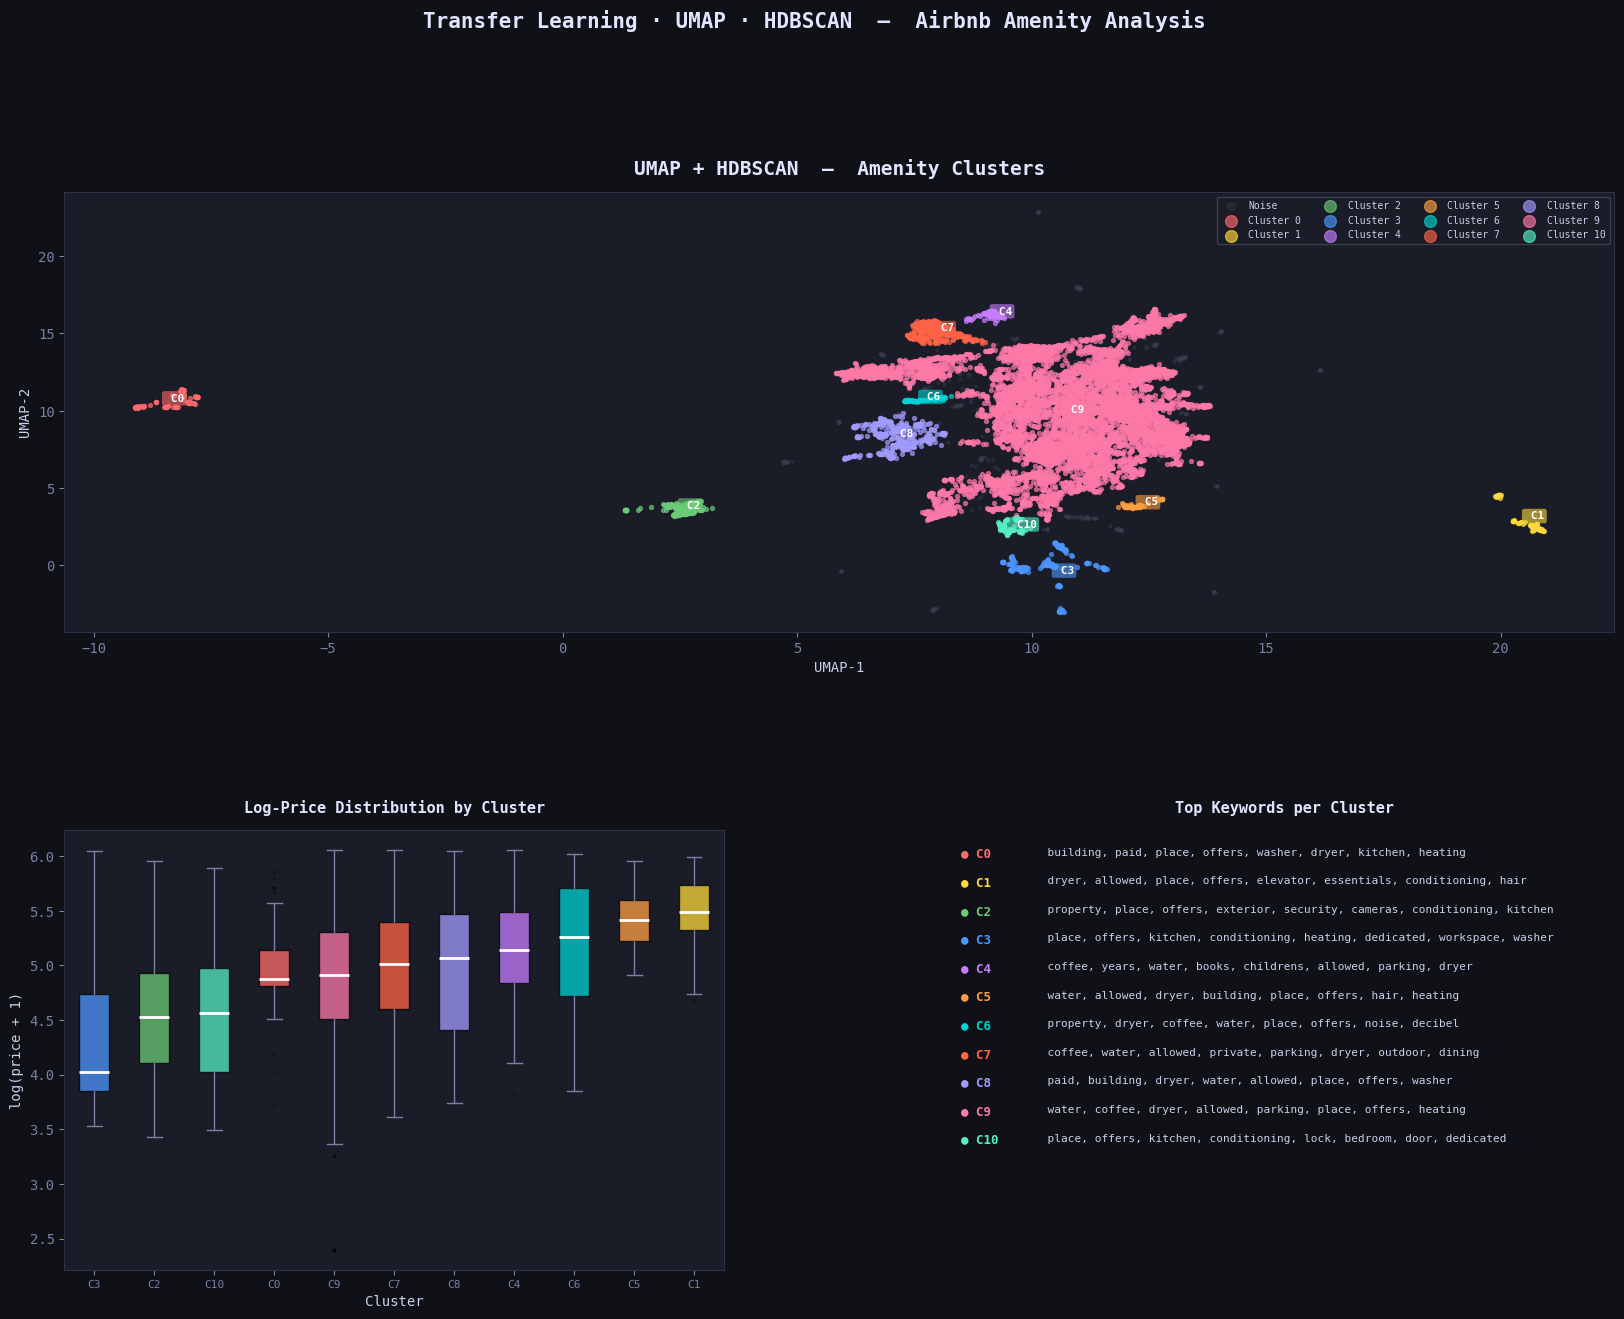

✔  Cluster plot saved → cluster_analysis.png

── Cluster Summary ──────────────────────────────────
 amenity_cluster  count  median_price  mean_price
              -1    452         165.0  187.869469
               0    135         130.0  151.688889
               1    121         242.0  250.355372
               2    284          91.5  110.098592
               3    290          55.0   91.427586
               4    125         170.0  187.176000
               5     83         224.0  228.698795
               6     80         192.0  203.475000
               7    527         150.0  167.650854
               8    485         158.0  170.129897
               9   9043         135.0  154.054075
              10     87          95.0  113.528736

[5/5]  Building model features …
✔  Train : 9,369  |  Test : 2,343
   Features : 38

── Neural Network  (cpu) ─────────────────────────
AirbnbNet(
  (net): Sequential(
    (0): Linear(in_features=38, out_features=256, bias=True)
    (1): BatchNorm1d

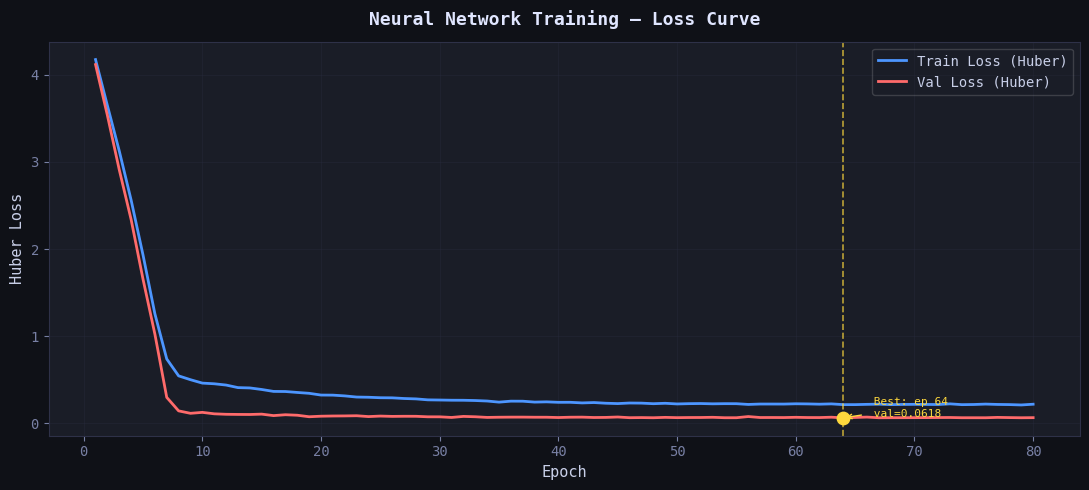

✔  Training curve saved → training_loss.png

  FINAL MODEL PERFORMANCE  (on test set)
  R²   : 0.5129
  MAE  : $41.58
  MSE  : 3,743.07
  RMSE : $61.18


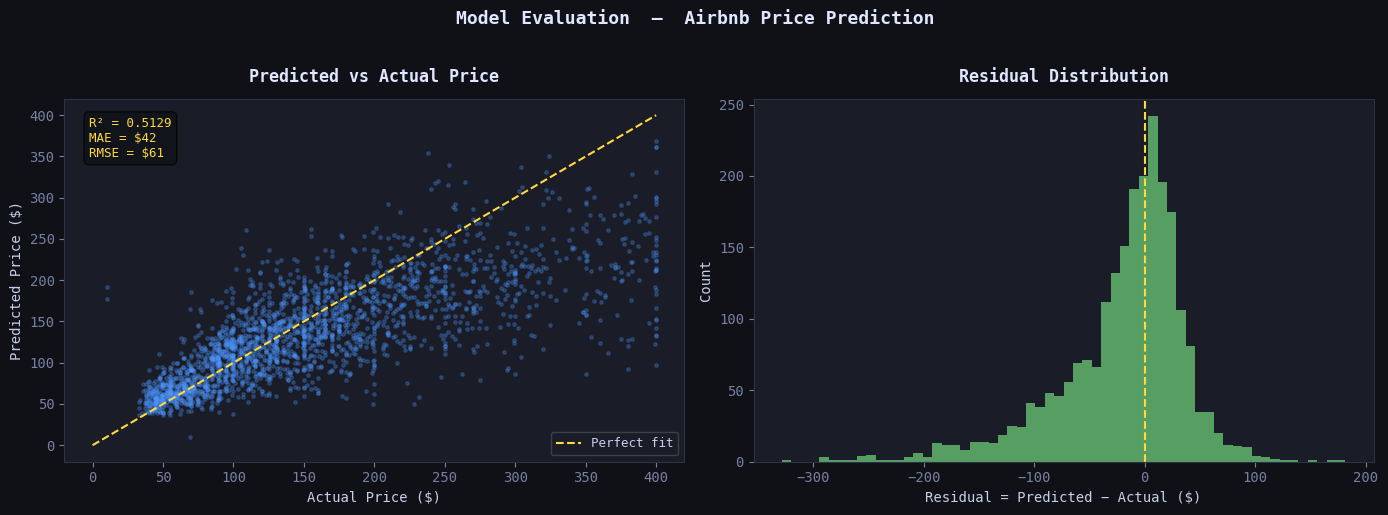

In [ ]:
# ============================================================
#  Airbnb Price Prediction — Transfer Learning Pipeline
#  sentence-transformers → UMAP → HDBSCAN → Neural Network
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns

# ── Embeddings & Clustering ──────────────────────────────────
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

# ── ML / Deep Learning ──────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ────────────────────────────────────────────────────────────
# 0.  STYLE
# ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3148",
    "axes.labelcolor":  "#c8cfe8",
    "xtick.color":      "#7880a4",
    "ytick.color":      "#7880a4",
    "text.color":       "#c8cfe8",
    "grid.color":       "#2e3148",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "axes.titlepad":    12,
})

PALETTE = [
    "#ff6b6b","#ffd93d","#6bcb77","#4d96ff","#c77dff",
    "#ff9f43","#00d2d3","#ff6348","#a29bfe","#fd79a8",
    "#55efc4","#fdcb6e","#e17055","#74b9ff","#b2bec3",
]

# ────────────────────────────────────────────────────────────
# 1.  LOAD DATA  (replace path as needed)
# ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  AIRBNB PRICE PREDICTION — TRANSFER LEARNING")
print("="*60)

# ↓ Change this to your actual file path
DATA_PATH = "datasets/Airbnb_NY_cleaned.csv"

import os, sys

if not os.path.exists(DATA_PATH):
    print(f"\n❌  ERROR: No se encontró el archivo '{DATA_PATH}'")
    print(f"   Ruta buscada : {os.path.abspath(DATA_PATH)}")
    print("   Por favor verifica que el archivo exista y que DATA_PATH sea correcto.")
    sys.exit(1)

data = pd.read_csv(DATA_PATH)
print(f"\n✔  Dataset cargado  →  {data.shape[0]:,} filas × {data.shape[1]} columnas")

# Build amenities_text if missing
if "amenities_text" not in data.columns:
    data["amenities_text"] = data["amenities"].astype(str)

data["amenities_text"] = data["amenities_text"].fillna("").astype(str)

def format_amenities(text: str) -> str:
    # Limpia corchetes, comillas y espacios extra
    text = text.replace("[", "").replace("]", "")
    text = text.replace("'", "").replace('"', "")
    text = text.strip().strip(",")
    # Convierte a oración natural con prefijo
    return "This place offers: " + text

data["amenities_text"] = data["amenities_text"].apply(format_amenities)

# ── Transformación logarítmica del precio ───────────────────
# log1p(x) = log(1 + x)  →  estabiliza la distribución sesgada
# del precio y evita que outliers dominen el entrenamiento.
# La columna original 'price' se conserva intacta.
data["log_price"] = np.log1p(data["price"])

print(f"\n── Distribución del precio ─────────────────────────────")
print(f"   price     →  min={data['price'].min():.2f}  "
      f"median={data['price'].median():.2f}  "
      f"max={data['price'].max():.2f}  "
      f"skew={data['price'].skew():.2f}")
print(f"   log_price →  min={data['log_price'].min():.3f}  "
      f"median={data['log_price'].median():.3f}  "
      f"max={data['log_price'].max():.3f}  "
      f"skew={data['log_price'].skew():.2f}")


# ────────────────────────────────────────────────────────────
# 2.  TRANSFER LEARNING — sentence-transformers embeddings
# ────────────────────────────────────────────────────────────
print("\n[1/5]  Generating sentence embeddings (transfer learning) …")

MODEL_NAME = "sentence-transformers/all-MiniLM-L12-v2"
st_model   = SentenceTransformer(MODEL_NAME)

embeddings = st_model.encode(
    data["amenities_text"].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"✔  Embeddings shape: {embeddings.shape}")   # (n, 384)


# ────────────────────────────────────────────────────────────
# 3.  UMAP  (dimensionality reduction)
# ────────────────────────────────────────────────────────────
print("\n[2/5]  UMAP dimensionality reduction …")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
    verbose=False,
)
umap_2d = reducer.fit_transform(embeddings)
print(f"✔  UMAP output shape: {umap_2d.shape}")


# ────────────────────────────────────────────────────────────
# 4.  HDBSCAN  (clustering)
# ────────────────────────────────────────────────────────────
print("\n[3/5]  HDBSCAN clustering …")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=80,
    min_samples=10,
    cluster_selection_epsilon=0.3,
    metric="euclidean",
    cluster_selection_method="eom",
)
cluster_labels = clusterer.fit_predict(umap_2d)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_pct   = (cluster_labels == -1).mean() * 100
print(f"✔  Clusters found : {n_clusters}")
print(f"   Noise points   : {noise_pct:.1f} %")

data["amenity_cluster"] = cluster_labels


# ────────────────────────────────────────────────────────────
# 5.  CLUSTER VISUALISATION
# ────────────────────────────────────────────────────────────
print("\n[4/5]  Plotting cluster analysis …")

# ── Top amenity keywords per cluster ────────────────────────
def top_words_per_cluster(df, col, label_col, top_n=8):
    results = {}
    for lbl in sorted(df[label_col].unique()):
        if lbl == -1:
            continue
        texts = " ".join(df.loc[df[label_col] == lbl, col].tolist()).lower()
        from collections import Counter
        import re
        words = re.findall(r"[a-záéíóúñ]{4,}", texts)
        stop  = {"with","that","this","from","have","wifi","free",
                 "alarm","carbon","monoxide","smoke"}
        freq  = Counter(w for w in words if w not in stop)
        results[lbl] = [w for w, _ in freq.most_common(top_n)]
    return results

keyword_map = top_words_per_cluster(data, "amenities_text", "amenity_cluster")

# ── Figure layout ────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.45, wspace=0.35)

ax_main  = fig.add_subplot(gs[0, :])   # full top row
ax_price = fig.add_subplot(gs[1, 0])
ax_kw    = fig.add_subplot(gs[1, 1])

fig.patch.set_facecolor("#0f1117")

# ── 5a. UMAP scatter coloured by cluster ────────────────────
unique_labels = sorted(set(cluster_labels))
cmap_list = []
for lbl in unique_labels:
    if lbl == -1:
        cmap_list.append("#3a3d4f")
    else:
        cmap_list.append(PALETTE[lbl % len(PALETTE)])

for lbl, col in zip(unique_labels, cmap_list):
    mask = cluster_labels == lbl
    label_txt = "Noise" if lbl == -1 else f"Cluster {lbl}"
    ax_main.scatter(
        umap_2d[mask, 0], umap_2d[mask, 1],
        c=col, s=4 if lbl == -1 else 8,
        alpha=0.35 if lbl == -1 else 0.65,
        label=label_txt, rasterized=True,
    )

ax_main.set_title("UMAP + HDBSCAN  —  Amenity Clusters",
                  fontsize=14, fontweight="bold", color="#e0e6ff")
ax_main.set_xlabel("UMAP-1")
ax_main.set_ylabel("UMAP-2")
ax_main.legend(loc="upper right", markerscale=3,
               fontsize=7, framealpha=0.2, ncol=4)

# Annotate cluster centroids
for lbl in [l for l in unique_labels if l != -1]:
    mask = cluster_labels == lbl
    cx, cy = umap_2d[mask, 0].mean(), umap_2d[mask, 1].mean()
    ax_main.annotate(f" C{lbl}", (cx, cy),
                     fontsize=8, color="white",
                     fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.2",
                               fc=PALETTE[lbl % len(PALETTE)],
                               alpha=0.6, lw=0))

# ── 5b. Price distribution per cluster ──────────────────────
valid = data[data["amenity_cluster"] != -1].copy()
order = (valid.groupby("amenity_cluster")["log_price"]
             .median().sort_values().index.tolist())
colors_order = [PALETTE[c % len(PALETTE)] for c in order]

bp = ax_price.boxplot(
    [valid.loc[valid["amenity_cluster"] == c, "log_price"].values
     for c in order],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color="#7880a4"),
    capprops=dict(color="#7880a4"),
    flierprops=dict(marker=".", color="#7880a4",
                    alpha=0.3, markersize=3),
)
for patch, col in zip(bp["boxes"], colors_order):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

ax_price.set_xticklabels([f"C{c}" for c in order], fontsize=8)
ax_price.set_title("Log-Price Distribution by Cluster",
                   fontsize=11, fontweight="bold", color="#e0e6ff")
ax_price.set_xlabel("Cluster")
ax_price.set_ylabel("log(price + 1)")

# ── 5c. Top keywords per cluster (text table) ────────────────
ax_kw.axis("off")
ax_kw.set_title("Top Keywords per Cluster",
                fontsize=11, fontweight="bold", color="#e0e6ff")

y_pos = 0.96
for lbl, words in keyword_map.items():
    col = PALETTE[lbl % len(PALETTE)]
    ax_kw.text(0.01, y_pos, f"● C{lbl}",
               transform=ax_kw.transAxes,
               fontsize=9, color=col, fontweight="bold", va="top")
    ax_kw.text(0.12, y_pos, "  " + ", ".join(words),
               transform=ax_kw.transAxes,
               fontsize=8, color="#c8cfe8", va="top")
    y_pos -= 0.065
    if y_pos < 0.02:
        break

plt.suptitle("Transfer Learning · UMAP · HDBSCAN  —  Airbnb Amenity Analysis",
             fontsize=15, fontweight="bold", color="#e0e6ff", y=1.01)

plt.savefig("cluster_analysis.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print("✔  Cluster plot saved → cluster_analysis.png")

# ── Print cluster summary ────────────────────────────────────
print("\n── Cluster Summary ──────────────────────────────────")
summary = (data.groupby("amenity_cluster")
               .agg(count=("price","count"),
                    median_price=("price","median"),
                    mean_price=("price","mean"))
               .reset_index()
               .sort_values("amenity_cluster"))
print(summary.to_string(index=False))


# ────────────────────────────────────────────────────────────
# 6.  FEATURE ENGINEERING & TRAIN / TEST SPLIT
# ────────────────────────────────────────────────────────────
print("\n[5/5]  Building model features …")

bool_cols = [c for c in data.columns
             if data[c].dtype == bool]
num_cols  = ["latitude","longitude","accommodates","bathrooms",
             "bedrooms","beds","review_scores_value",
             "amenities_count","distance_min"]

# One-hot for cluster (exclude noise = -1 → map to 0)
data["amenity_cluster_safe"] = data["amenity_cluster"].clip(lower=0)
cluster_dummies = pd.get_dummies(
    data["amenity_cluster_safe"],
    prefix="cluster"
).astype(float)

feature_df = pd.concat([
    data[num_cols].astype(float),
    data[bool_cols].astype(float),
    cluster_dummies,
], axis=1)

target = data["log_price"].values          # ya transformado con log1p

X = feature_df.values.astype(np.float32)
y = target.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f"✔  Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print(f"   Features : {X_train.shape[1]}")


# ────────────────────────────────────────────────────────────
# 7.  NEURAL NETWORK
# ────────────────────────────────────────────────────────────
INPUT_DIM  = X_train.shape[1]
HIDDEN     = [256, 128, 64, 32]
DROPOUT    = 0.30
LR         = 1e-3
EPOCHS     = 80
BATCH      = 256
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\n── Neural Network  ({DEVICE}) ─────────────────────────")


class AirbnbNet(nn.Module):
    def __init__(self, in_dim, hidden_dims, dropout):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


model = AirbnbNet(INPUT_DIM, HIDDEN, DROPOUT).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\n   Total params : {total_params:,}")

# ── DataLoaders ──────────────────────────────────────────────
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.HuberLoss(delta=1.0)

# ── Training loop ────────────────────────────────────────────
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # — train
    model.train()
    running = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * len(xb)
    train_losses.append(running / len(train_ds))

    # — validate
    model.eval()
    val_run = 0.0
    with torch.no_grad():
        for xb, yb in test_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_run += criterion(model(xb), yb).item() * len(xb)
    val_losses.append(val_run / len(test_ds))
    scheduler.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  "
              f"train={train_losses[-1]:.4f}  "
              f"val={val_losses[-1]:.4f}")

print("✔  Training complete")


# ────────────────────────────────────────────────────────────
# 8.  TRAINING CURVE PLOT
# ────────────────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(11, 5))
fig2.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1a1d27")

epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, train_losses, color="#4d96ff",
        lw=2, label="Train Loss (Huber)")
ax.plot(epochs_range, val_losses,   color="#ff6b6b",
        lw=2, label="Val Loss (Huber)")

# Best val epoch marker
best_ep  = np.argmin(val_losses) + 1
best_val = min(val_losses)
ax.axvline(best_ep, color="#ffd93d", lw=1.2, ls="--", alpha=0.7)
ax.scatter([best_ep], [best_val], color="#ffd93d", s=80, zorder=5)
ax.annotate(f" Best: ep {best_ep}\n val={best_val:.4f}",
            xy=(best_ep, best_val),
            xytext=(best_ep + 2, best_val + 0.01),
            color="#ffd93d", fontsize=8,
            arrowprops=dict(arrowstyle="->", color="#ffd93d", lw=1))

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Huber Loss", fontsize=11)
ax.set_title("Neural Network Training — Loss Curve",
             fontsize=13, fontweight="bold", color="#e0e6ff")
ax.legend(fontsize=10, framealpha=0.2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_loss.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print("✔  Training curve saved → training_loss.png")


# ────────────────────────────────────────────────────────────
# 9.  EVALUATION METRICS
# ────────────────────────────────────────────────────────────
model.eval()
preds_log, true_log = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(DEVICE)
        preds_log.append(model(xb).cpu().numpy())
        true_log.append(yb.numpy())

preds_log = np.concatenate(preds_log)
true_log  = np.concatenate(true_log)

# Inverse log-transform
preds_price = np.expm1(preds_log)
true_price  = np.expm1(true_log)

r2  = r2_score(true_price, preds_price)
mae = mean_absolute_error(true_price, preds_price)
mse = mean_squared_error(true_price, preds_price)
rmse = np.sqrt(mse)

print("\n" + "="*60)
print("  FINAL MODEL PERFORMANCE  (on test set)")
print("="*60)
print(f"  R²   : {r2:.4f}")
print(f"  MAE  : ${mae:,.2f}")
print(f"  MSE  : {mse:,.2f}")
print(f"  RMSE : ${rmse:,.2f}")
print("="*60)

# ── Predicted vs Actual scatter ──────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))
fig3.patch.set_facecolor("#0f1117")

for ax in axes:
    ax.set_facecolor("#1a1d27")

# scatter
p_clip = np.clip(preds_price, 0, np.percentile(true_price, 99))
t_clip = np.clip(true_price,  0, np.percentile(true_price, 99))

axes[0].scatter(t_clip, p_clip, alpha=0.25, s=6,
                color="#4d96ff", rasterized=True)
lim = max(t_clip.max(), p_clip.max())
axes[0].plot([0, lim], [0, lim], color="#ffd93d", lw=1.5,
             ls="--", label="Perfect fit")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Predicted vs Actual Price",
                  fontweight="bold", color="#e0e6ff")
axes[0].legend(fontsize=9, framealpha=0.2)

stats_txt = (f"R² = {r2:.4f}\n"
             f"MAE = ${mae:,.0f}\n"
             f"RMSE = ${rmse:,.0f}")
axes[0].text(0.04, 0.95, stats_txt,
             transform=axes[0].transAxes, va="top",
             fontsize=9, color="#ffd93d",
             bbox=dict(boxstyle="round,pad=0.4",
                       fc="#0f1117", alpha=0.7))

# residuals
residuals = preds_price - true_price
axes[1].hist(np.clip(residuals, -500, 500), bins=60,
             color="#6bcb77", alpha=0.75, edgecolor="none")
axes[1].axvline(0, color="#ffd93d", lw=1.5, ls="--")
axes[1].set_xlabel("Residual = Predicted − Actual ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution",
                  fontweight="bold", color="#e0e6ff")

plt.suptitle("Model Evaluation  —  Airbnb Price Prediction",
             fontsize=13, fontweight="bold",
             color="#e0e6ff", y=1.02)
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
